<a href="https://colab.research.google.com/github/jorgekundig/sprint9/blob/main/sprint9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sprint 9

IT Academy - Análisis de Datos

P2P: Ángel Herrezuelo

### Descripción:
En este sprint trabajarás la interpretación analítica y el storytelling basado en datos, podrás utilizar la base de datos que tienes disponible en BigQuery o bien la base de datos creada con MySQL en el Sprint 2, a partir del ejercicio 8, y aprenderás a construir visualizaciones en Python como alternativa programática a las herramientas de BI.

El objetivo es aprender a generar gráficos en Python y utilizarlos para responder preguntas de negocio. Además, deberás justificar las decisiones tomadas y comunicar los resultados de manera clara y argumentada.

Tu papel como analista será:
* Entender que se te está preguntando desde el punto de vista del negocio.
* Decidir qué visualizaciones son adecuadas para responder cada pregunta.
* Construir estas visualizaciones en Python.
* Interpretar correctamente qué muestran los datos.
* Detectar posibles sesgos, limitaciones o riegos en el análisis.
* Proponer acciones de negocio fundamentadas en datos.

Este sprint pone el énfasis en el uso de Python como herramienta de análisis visual, en el criterio analítico y en la capacidad de transformar gráficos en decisiones, más que en la sofisticación técnica. Procura que tu código sea claro y organizado.


## Nivel 1 - Visualización analítica guiada en Python

El objetivo del nivel es aplicar criterio analítico para responder preguntas de negocio mediante visualizaciones en Python, trabajando con las tablas del modelo del Sprint 2 a partir del ejercicio 8, cargadas como DataFrame independientes.

En este nivel no se pide construir un dataset final ni unificar todas las tablas, sino:
* Identificar qué información es necesaria.
* Elegir correctamente la tabla (o tablas) relevante(s).
* Construir visualizaciones adecuadas.
* Interpretar los resultados obtenidos.

Este nivel pone el énfasis en pensar antes de programar.

### Ex. 1: Preguntas analíticas directas (sin integraciones complejas)

**Contexto:** Se trabaja con una sola tabla a la vez, elegida según la pregunta analítica. No hace falta hacer merge entre tablas ni definir funciones avanzadas.

Aspectos a revisar y analizar:
* Identificar qué información es necesaria
* Qué DataFrame es el más adecuado para responder la pregunta.
* Elegir correctamente la tabla (o tablas) relevante(s).
* Tipos de variables implicadas.
* Elección del tipo de gráfico.

Preguntas analíticas: (sólo utilizando la tabla de transacciones):
1. ¿Cómo evoluciona el número de transacciones a lo largo del tiempo? Ejemplo de pasos guiados con pandas:
    * Selecciona la columna temporal adecuada.
    * Define el nivel temporal de análisis.
    * Cuenta el número de registros por período temporal.
    * Ordena los resultados cronológicamente.
    * Visualiza la evolución con un gráfico de líneas con pandas.
2. ¿Qué usuarios generan más volumen de facturación? Ejemplo de pasos guiados con seaborn:
    * Identifica la columna que representa al usuario.
    * Agrupa las transacciones por usuario y calcula el volumen total de facturación sumando la columna amount.
    * Ordena los usuarios de mayor a menor volumen de facturación.
    * Selecciona los N usuarios principales (por ejemplo, los 15 primeros).
    * Representa el resultado mediante un gráfico de barras utilizando Seaborn
3. ¿Hay diferencias en la distribución del importe de las transacciones según la hora del día y si han sido aceptadas o rechazadas? Ejemplo de pasos guiados con seaborn:
    * Crea una nueva columna con la hora del día a partir del timestamp.
    * Utiliza un violinplot de seaborn para analizar la distribución de los importes.
    * Asigna: x para la hora del día, y para el importe de la transacción y hue para el estado de la transacción.
    * Activa split para comparar aceptadas y rechazadas y inner con cuartil para mostrar mediana y cuartiles.
4. ¿En qué días de la semana se concentra más actividad de venta?

Para cada pregunta:
* Construye una visualización sencilla en Python sin utilizar IA.
* Interpreta brevemente el resultado obtenido.
* Utiliza las herramientas de IA disponibles en Colab para proponer una visualización alternativa.
* Compara el resultado inicial con el resultado propuesto por la IA y valora críticamente si la nueva propuesta es una mejora o un empeoramiento, justificando tu decisión.

In [1]:
# Importar librerías:

from datetime import date
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyodbc
import locale

In [2]:
# Conexión a MySQL para extraer dataframe transactions

Cadena_Conexion = (
    f'Driver={{MariaDB ODBC 3.1 Driver}};'
    f'Server={r'localhost'};'
    f'Database={'operations'};'
    f'UID={r'root'};'
    f'PWD={r'root2025'};'
    f'PORT={3306};'
)

conexion = pyodbc.connect(Cadena_Conexion)
df_transactions = pd.read_sql("SELECT * FROM transactions", conexion)
df_transactions.rename(columns={'id': 'transaction_id', 'business_id': 'company_id'}, inplace=True)

/var/folders/ml/6tvhfsz115n38k7_180gd7n80000gn/T/ipykernel_75033/419660731.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_transactions = pd.read_sql("SELECT * FROM transactions", conexion)


In [3]:
df_evo_trans = df_transactions.groupby(df_transactions['timestamp'].dt.strftime('%Y-%m')).agg(total_transactions=('transaction_id', 'count')).reset_index()
df_evo_trans

,timestamp,total_transactions
0,2015-01,818
1,2015-02,816
2,2015-03,835
3,2015-04,829
4,2015-05,812
...,...,...
115,2024-08,824
116,2024-09,827
117,2024-10,823
118,2024-11,816


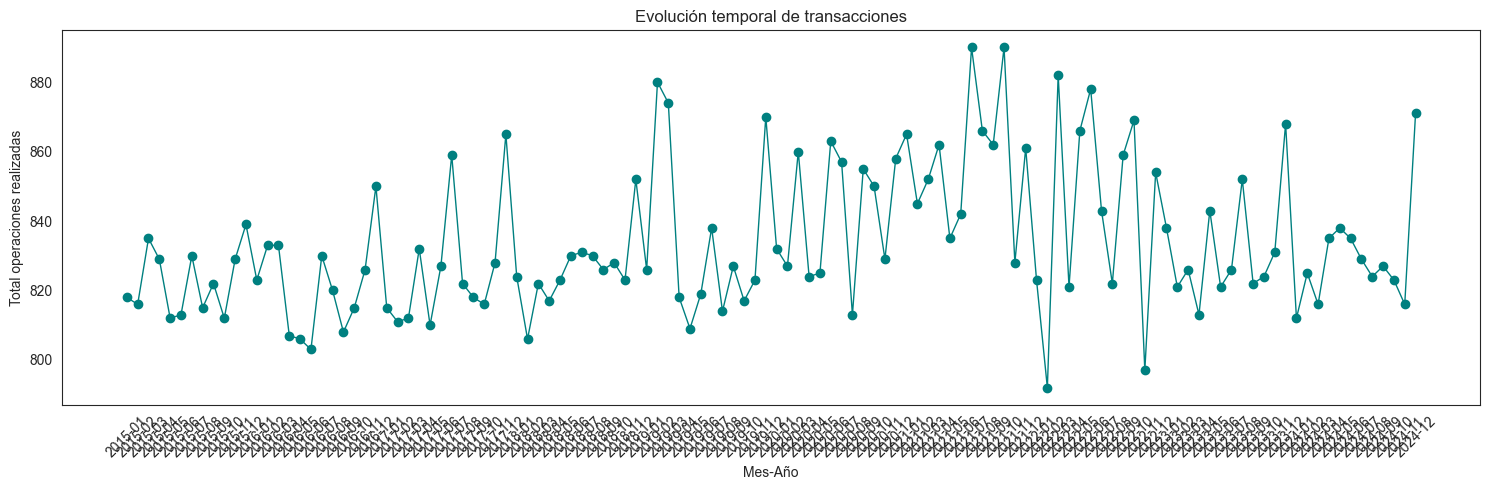

In [4]:
# Gráfico lineal

fechas = df_evo_trans['timestamp']
total_trans = df_evo_trans['total_transactions']
sns.set_style("white")
plt.figure(figsize=(15,5))
plt.title("Evolución temporal de transacciones")
plt.plot(fechas, total_trans, color='teal', linewidth=1, marker='o')
plt.xlabel('Mes-Año')
plt.ylabel('Total operaciones realizadas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

***Interpretación:***
- Con el transcurso de los años, el número de operaciones ha tenido una línea ascendente hasta el año 2022.
- La visualización dificulta notar los meses de cada año. Sin embargo, podemos notar que para la mayoría de los años, la cantidad de transacciones fluctúa a lo largo del año.
- El movimiento más dramático se da a partir de mediados del 2021, donde se alcanza el mayor número de transacciones, para caer a inicios del 2022 al punto más bajo.
- En el periodo más reciente del análisis, el 2024 presentaba una caida gradual desde mediados de año, pero se da un repunte a inicios del 2025.
- A pesar de todo, la cantidad de operaciones se mantiene dentro de un rango entre 792 y 890 operaciones, con la mayoría de ellas cercanas a la mediana (827)
- Al ejecutar el código en VS Code, el eje muestra los meses y años amontonados, entendible pues son 120 registros. Revisaremos el código en Colab con ayuda de la IA para mejorar este aspecto.

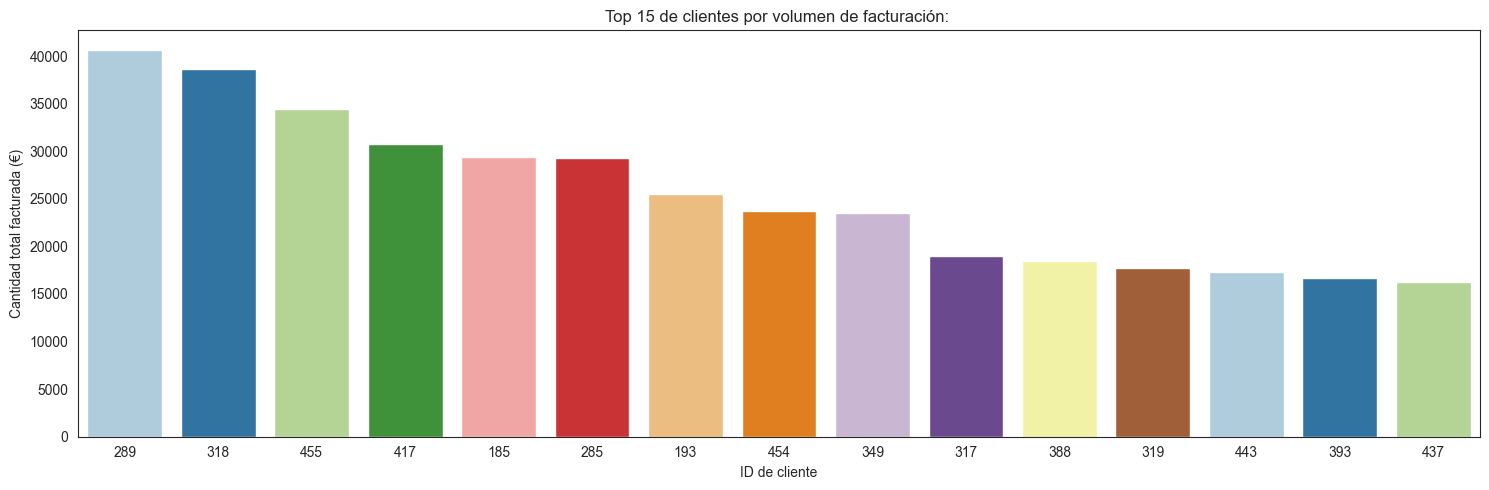

In [5]:
# 2. Usuarios con mayor volumen de facturación
# Primero filtramos el df para quedarnos únicamente con las transacciones finalizadas (declined = 0).
# Reconvertimos a dataframe (había quedado como serie) y ordenamos por importe, de mayor a menor.
# Nos quedamos con los primeros 15 para generar el gráfico, un barplot de seaborn.

df_trans_filt = df_transactions[df_transactions['declined'] == 0]
df_trans_filt = pd.DataFrame(df_trans_filt.groupby('user_id')['amount'].sum())
df_trans_filt.sort_values(by='amount', ascending=False, inplace=True)
df_top15_fact = df_trans_filt.head(15).reset_index()
sns.set_style("white")
plt.figure(figsize=(15,5))
plt.title("Top 15 de clientes por volumen de facturación: ")
sns.barplot(
    x= "user_id",
    y= "amount",
    data= df_top15_fact,
    palette= 'Paired',
    hue='user_id',
    order= df_top15_fact['user_id'],
    )
plt.xlabel("ID de cliente")
plt.ylabel("Cantidad total facturada (€)")
plt.tight_layout()
plt.show()

***Interpretación:***
- En este caso, al trabajar únicamente con la tabla de transacciones, el gráfico no nos dice demasiado de los clientes pues sólo vemos su número de ID.
- El top 15 de clientes por volumen de facturación parece estar muy por encima de la media (5166.04), con un máximo que supera los 40000 €.
- El cliente número 15 supera los 16000 € en facturación.

In [6]:
# 3. Distribución del importe por hora del día y status
# Creación de nueva columna 'hour' partiendo del timestamp

df_transactions['hour'] = df_transactions['timestamp'].dt.hour
columna_hora = df_transactions.pop('hour')
indice_timestamp = df_transactions.columns.get_loc('timestamp')
df_transactions.insert(indice_timestamp +1, 'hour', columna_hora)
df_transactions

,transaction_id,card_id,company_id,timestamp,hour,amount,declined,product_ids,user_id,lat,longitude
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,7,395.43,0,"16, 26, 97, 87",4713,46.1999,1.43554
1,00045D6B-ED2E-4F2F-8186-CEE074D875D0,CcS-6699,b-2390,2020-07-14 15:37:45,15,326.01,0,"30, 11, 16, 81",2118,29.7573,-95.37960
2,000481C3-1C26-4FEF-83A0-4CD0EB004BBD,CcS-6696,b-2230,2017-09-04 19:44:53,19,161.60,0,72,2115,53.5489,-113.50300
3,00051AA4-9CBE-4268-B070-C38062A1B3E2,CcS-7606,b-2266,2017-01-05 18:19:25,18,148.91,0,18,3025,52.2084,5.69081
4,0008A312-EDFE-4A4F-BC99-E9C92EC3CA4D,CcU-3358,b-2598,2023-09-23 04:51:43,4,294.59,0,"35, 33, 19",215,53.5535,-113.49900
...,...,...,...,...,...,...,...,...,...,...,...
99994,FFF9E3CE-234E-408C-A8EF-F9CAD577224A,CcS-5010,b-2234,2022-12-17 20:57:55,20,247.39,0,"20, 42, 54, 46",429,52.5223,13.40490
99995,FFFB270D-F53A-4D5D-9666-E5307C53CC84,CcS-7655,b-2522,2024-05-13 03:42:03,3,349.13,0,"30, 87, 5, 66",3074,39.0271,-8.10523
99996,FFFC9E8D-27C7-4ADE-98F2-7533EF4DF126,CcS-5589,b-2302,2019-10-30 02:31:37,2,234.22,0,"16, 49",1008,59.3327,18.07530
99997,FFFCF76D-ECF0-4985-A2D0-B2A7B75998FC,CcS-5261,b-2250,2023-06-17 19:10:30,19,148.91,0,18,680,52.0635,4.30862


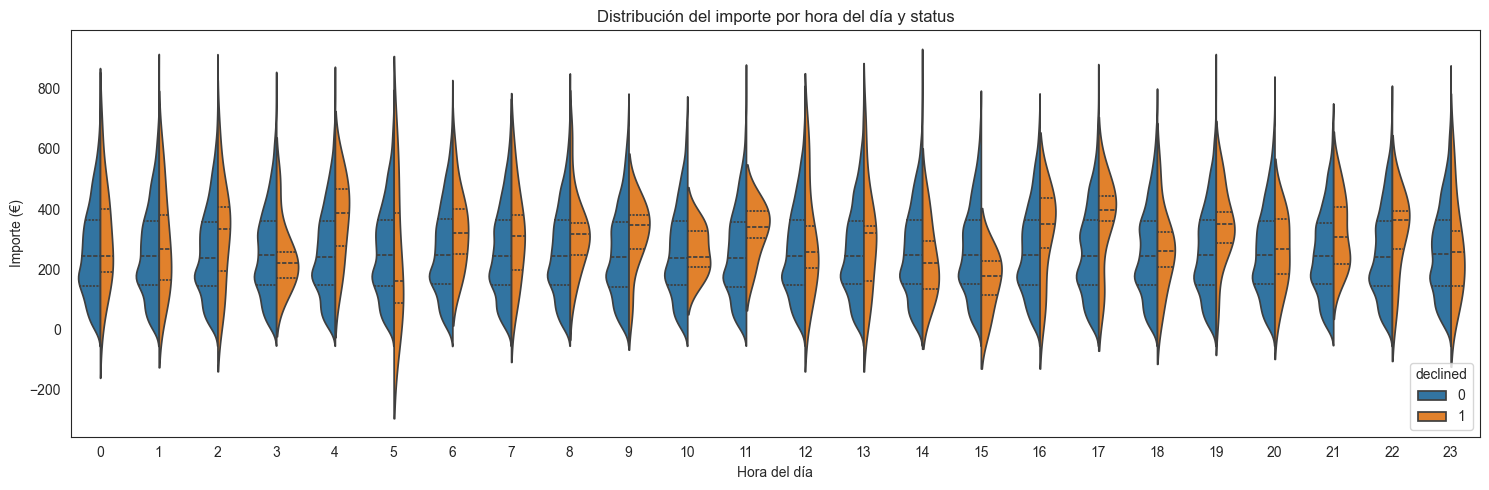

In [7]:
# Creación del violinplot

sns.set_style("white")
plt.figure(figsize=(15,5))
plt.title("Distribución del importe por hora del día y status")
sns.violinplot(
    data=df_transactions,
    x='hour',
    y='amount',
    hue='declined',
    split=True,
    inner='quartile'
)
plt.xlabel("Hora del día")
plt.ylabel("Importe (€)")
plt.tight_layout()
plt.show()

***Interpretación:***
- Al tener 24 violinplots a evaluar a la vez, el gráfico tampoco facilita un análisis sencillo de los datos. Podría resultar conveniente en el futuro evaluar por franjas horarias, más que por la hora del día.
- También podría ser más útil un boxplot para comparar de forma más sencilla la mediana, outliers y el rango intercuartílico.
- Dicho esto, a simple vista no se observan diferencias importantes como para determinar si la hora del día influye en el importe de las transacciones, o en que sean aceptadas o rechazadas.

In [8]:
# 4. Distribución de la venta por día de la semana

locale.setlocale(locale.LC_TIME, 'es_ES')

df_venta_semana = df_transactions.groupby(df_transactions['timestamp'].dt.strftime('%A')).agg(weekday_transactions_total=('transaction_id', 'count')).reset_index()
indice_dia_max = df_venta_semana['weekday_transactions_total'].idxmax()
dia_max = df_venta_semana.iat[indice_dia_max, 0]
max_transacciones = df_venta_semana['weekday_transactions_total'].max()
print(f'El día de la semana con mayor actividad de venta es el {dia_max}, con {max_transacciones} operaciones')
df_venta_semana

El día de la semana con mayor actividad de venta es el jueves, con 14516 operaciones


,timestamp,weekday_transactions_total
0,domingo,14289
1,jueves,14516
2,lunes,14122
3,martes,14176
4,miércoles,14271
5,sábado,14353
6,viernes,14272


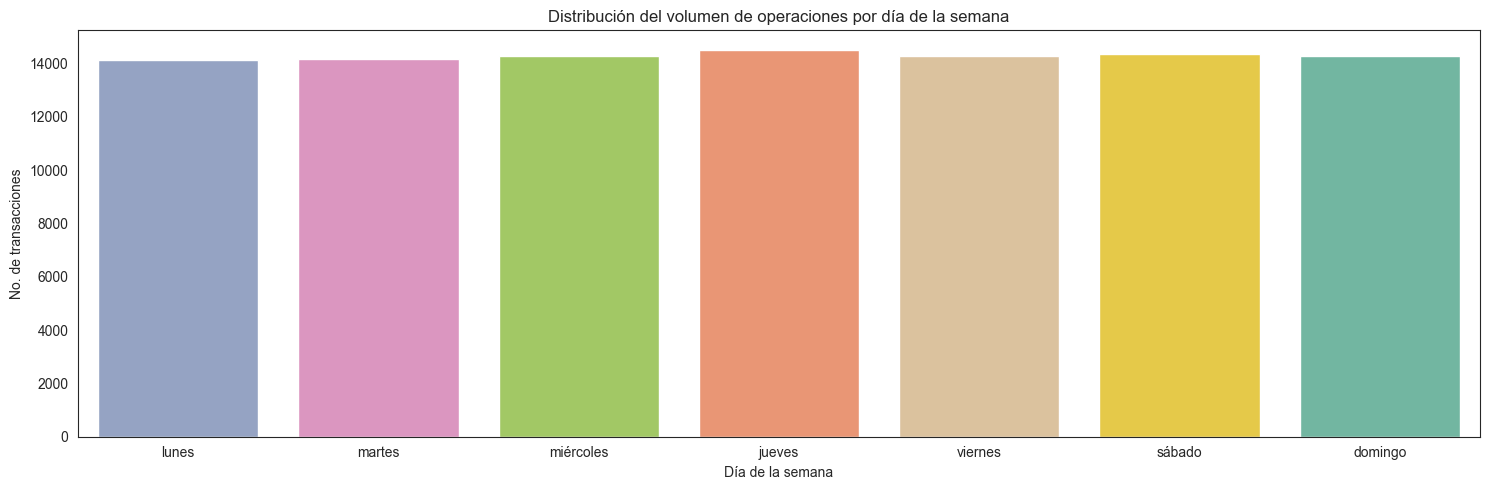

In [9]:
# Creación del gráfico de barras

orden_semana = ['lunes', 'martes', 'miércoles', 'jueves', 'viernes', 'sábado', 'domingo']
sns.set_style("white")
plt.figure(figsize=(15,5))
plt.title("Distribución del volumen de operaciones por día de la semana")
sns.barplot(
    x= "timestamp",
    y= "weekday_transactions_total",
    data= df_venta_semana,
    palette= 'Set2',
    hue='timestamp',
    order=orden_semana
)
plt.xlabel("Día de la semana")
plt.ylabel("No. de transacciones")
plt.tight_layout()
plt.show()

***Interpretación:***

- No apreciamos una variabilidad considerable en el volumen de operaciones entre los diferentes días de la semana.
- Si bien el jueves es el día de mayor actividad, el resto de la semana mantiene un volumen similar, entre 14122 y 14353 operaciones.
- Podríamos decir que en general, cada día se realiza un poco más de 14000 operaciones.

## Mejoras con IA:
Consultamos a la herramienta de IA de Colab (Gemini 2.5) para mejorar los gráficos realizados u obtener una propuesta de gráfico alternativa, que iremos mostrando a continuación:

***1. Evolución temporal de transacciones (gráfico de línea)***

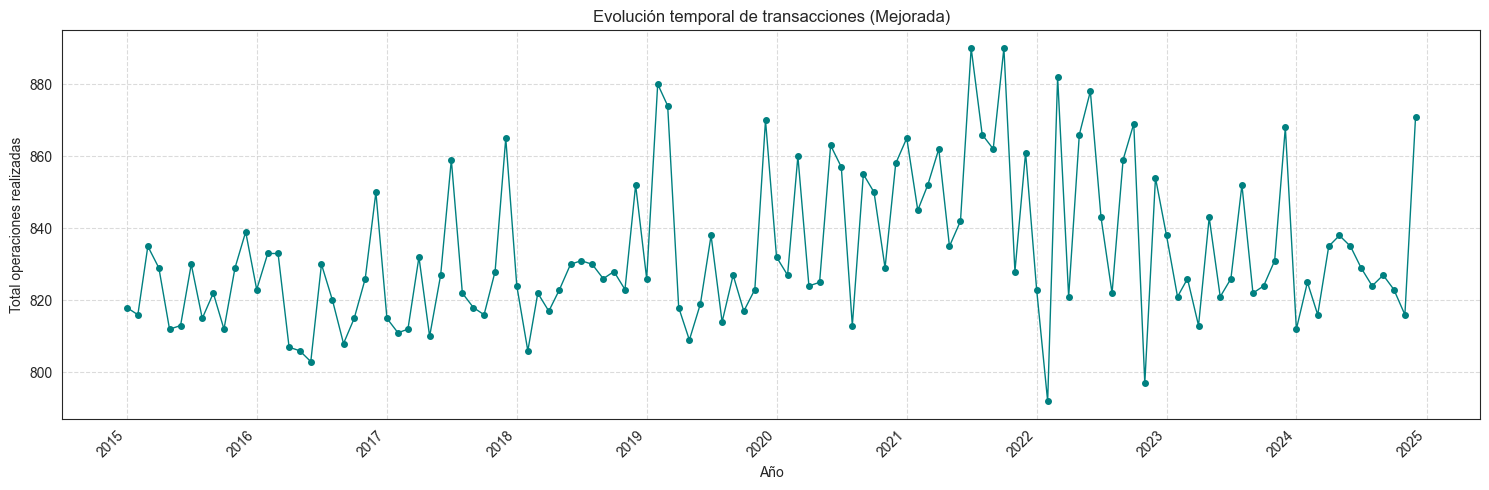

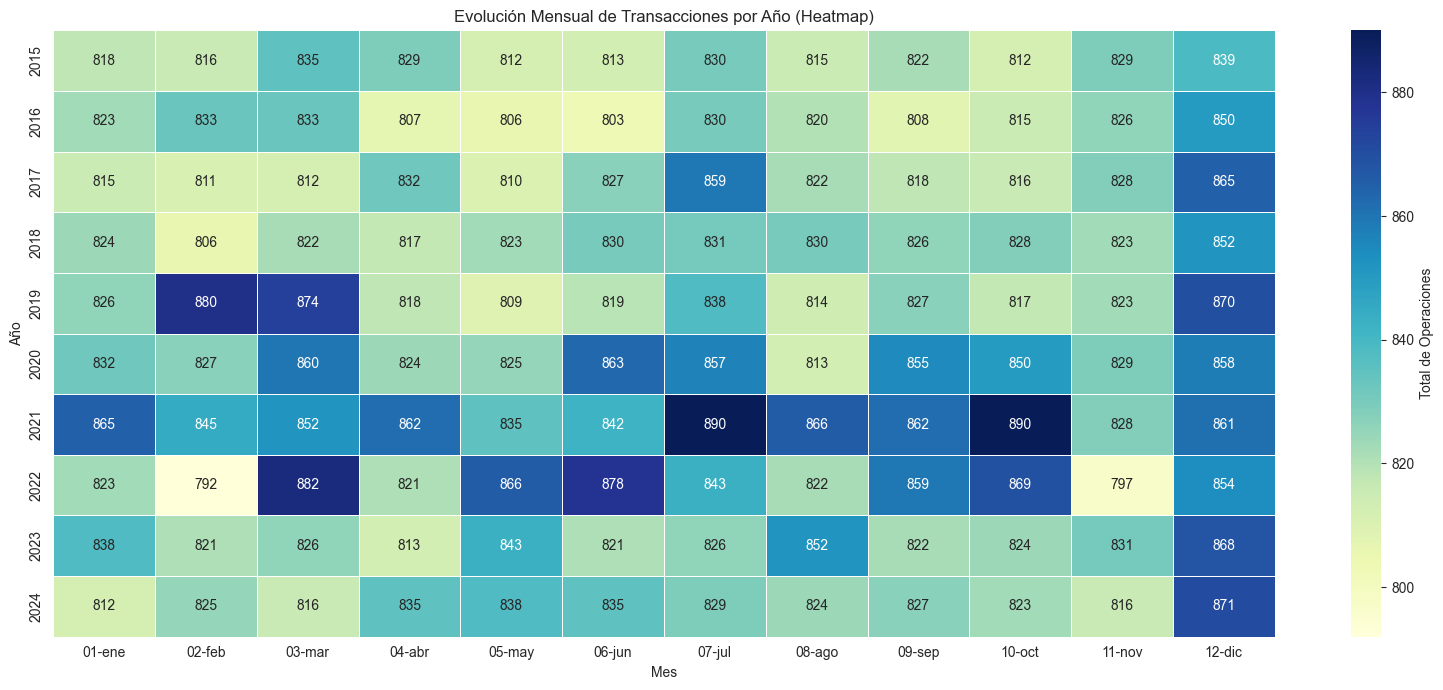

In [10]:
# Propuesta Gemini:

import matplotlib.dates as mdates
import locale

# Asegúrate de que la columna 'timestamp' de df_evo_trans sea de tipo datetime
# Si ya está en formato string '%Y-%m', conviértela primero.
# La conversión explícita asegura el tipo correcto para la manipulación de fechas.
df_evo_trans['timestamp_dt'] = pd.to_datetime(df_evo_trans['timestamp'], format='%Y-%m')

fechas_dt = df_evo_trans['timestamp_dt']
total_trans = df_evo_trans['total_transactions']

sns.set_style("white")
plt.figure(figsize=(15,5))
plt.title("Evolución temporal de transacciones (Mejorada)")
plt.plot(fechas_dt, total_trans, color='teal', linewidth=1, marker='o', markersize=4)
plt.xlabel('Año') # Cambiado el label a Año ya que las marcas principales son anuales
plt.ylabel('Total operaciones realizadas')

# Mejorar la legibilidad del eje x para evitar amontonamiento
# Configurar el localizador y formateador principal para años
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Opcionalmente, configurar localizadores menores para meses, pero sin formateador para evitar amontonamiento
# plt.gca().xaxis.set_minor_locator(mdates.MonthLocator(interval=3)) # Mostrar cada 3 meses, por ejemplo

plt.xticks(rotation=45, ha='right') # Rotar y alinear a la derecha para un mejor ajuste
plt.grid(True, linestyle='--', alpha=0.7) # Añadir una cuadrícula para una mejor legibilidad
plt.tight_layout()
plt.show()

# Propuesta de gráfico alternativo: Heatmap para visualizar la evolución temporal y estacionalidad
plt.figure(figsize=(16, 7))

# Establecer el locale para que strftime use nombres de meses en español
locale.setlocale(locale.LC_TIME, 'es_ES.UTF-8') # Asegurarse de que el locale es consistente

# Extraer año y mes para el heatmap desde la columna datetime recién creada
df_evo_trans_heatmap = df_evo_trans.copy()
df_evo_trans_heatmap['year'] = df_evo_trans_heatmap['timestamp_dt'].dt.year
# Usar strftime para asegurar el formato de mes deseado (ej. '01-ene')
df_evo_trans_heatmap['month'] = df_evo_trans_heatmap['timestamp_dt'].dt.strftime('%m-%b')

# Crear la tabla pivote para el heatmap
pivot_table_transactions = df_evo_trans_heatmap.pivot(index='year', columns='month', values='total_transactions')

# Reordenar las columnas de los meses cronológicamente para el heatmap, usando abreviaturas en español en minúsculas
month_order_heatmap = [
    f"{i:02d}-{m.lower()}" for i, m in enumerate([
        'Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
        'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'
    ], 1)
]
pivot_table_transactions = pivot_table_transactions.reindex(columns=month_order_heatmap)

sns.heatmap(pivot_table_transactions, cmap="YlGnBu", annot=True, fmt="d", linewidths=.5, cbar_kws={'label': 'Total de Operaciones'})
plt.title('Evolución Mensual de Transacciones por Año (Heatmap)')
plt.xlabel('Mes')
plt.ylabel('Año')
plt.tight_layout()
plt.show()

**Evaluación:**

Las mejoras para el gráfico lineal ayudaron a mejorar la legibilidad del eje x, pero en el fondo sigue siendo una línea temporal con demasiados registros, en los que además no podemos ver el mes exacto.

Por otro lado, la propuesta de heatmap es interesante pues permite ir mirando año a año la evolución. Le ha costado un poco llegar al gráfico debido al formato original de la columna timestamp y el locale, pero el resultado me parece bastante bueno.

***2. Usuarios con mayor volumen de facturación (barplot)***




/var/folders/ml/6tvhfsz115n38k7_180gd7n80000gn/T/ipykernel_75033/2519824823.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


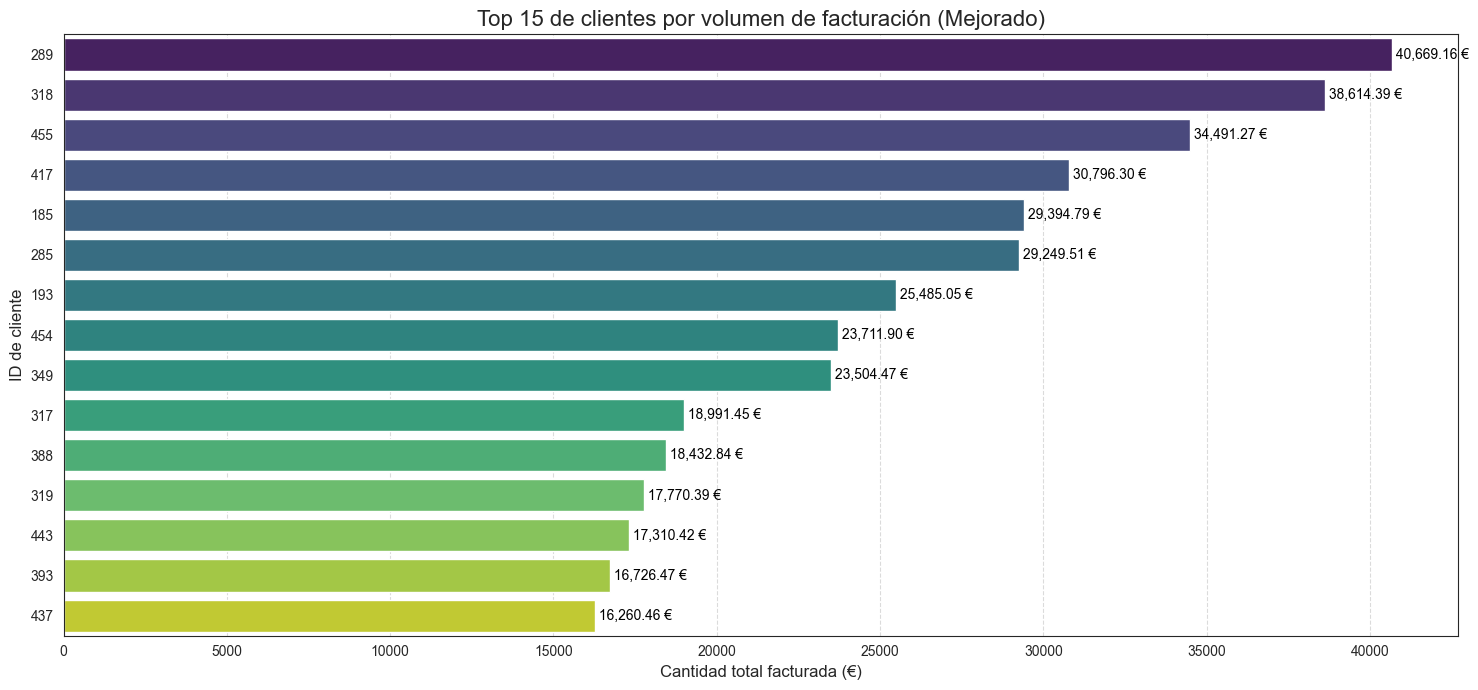

In [11]:
# Propuesta Gemini:
import matplotlib.pyplot as plt
import seaborn as sns

# Preparación de los datos (manteniendo la lógica original del usuario)
df_trans_filt = df_transactions[df_transactions['declined'] == 0]
df_trans_filt = pd.DataFrame(df_trans_filt.groupby('user_id')['amount'].sum())
df_trans_filt.sort_values(by='amount', ascending=False, inplace=True)
df_top15_fact = df_trans_filt.head(15).reset_index()

sns.set_style("white")
plt.figure(figsize=(15, 7))

# Gráfico de barras horizontal mejorado
sns.barplot(
    x="amount",
    y="user_id", # Cambiado a y para barras horizontales
    data=df_top15_fact,
    palette='viridis', # Nueva paleta de colores para mayor contraste
    order=df_top15_fact['user_id'] # Mantener el orden por volumen de facturación
)

plt.title("Top 15 de clientes por volumen de facturación (Mejorado)", fontsize=16)
plt.xlabel("Cantidad total facturada (€)", fontsize=12)
plt.ylabel("ID de cliente", fontsize=12)
plt.ticklabel_format(style='plain', axis='x') # Evitar notación científica en el eje X

# Añadir etiquetas de valor a las barras
for index, row in df_top15_fact.iterrows():
    plt.text(row.amount, index, f' {row.amount:,.2f} €', color='black', ha="left", va='center')

plt.grid(axis='x', linestyle='--', alpha=0.7) # Añadir cuadrícula solo en el eje X
plt.tight_layout()
plt.show()


**Evaluación:**

Las barras horizontales también mejoran mucho la legibilidad del gráfico. Adicionalmente, el tener los valores de cada barra al final también da mucha más claridad y nos evita estar interpretando los resultados a ojo. La paleta de colores también da un buen contraste y facilita la lectura. La única mejora que podría tener la IA sería especificar el hue y legend=False para evitar el warning que aparece cuando se usa palette sin especificar hue, y que en futuras versiones generará error.

***3. Distribución del importe por hora del día y status (violinplot)***



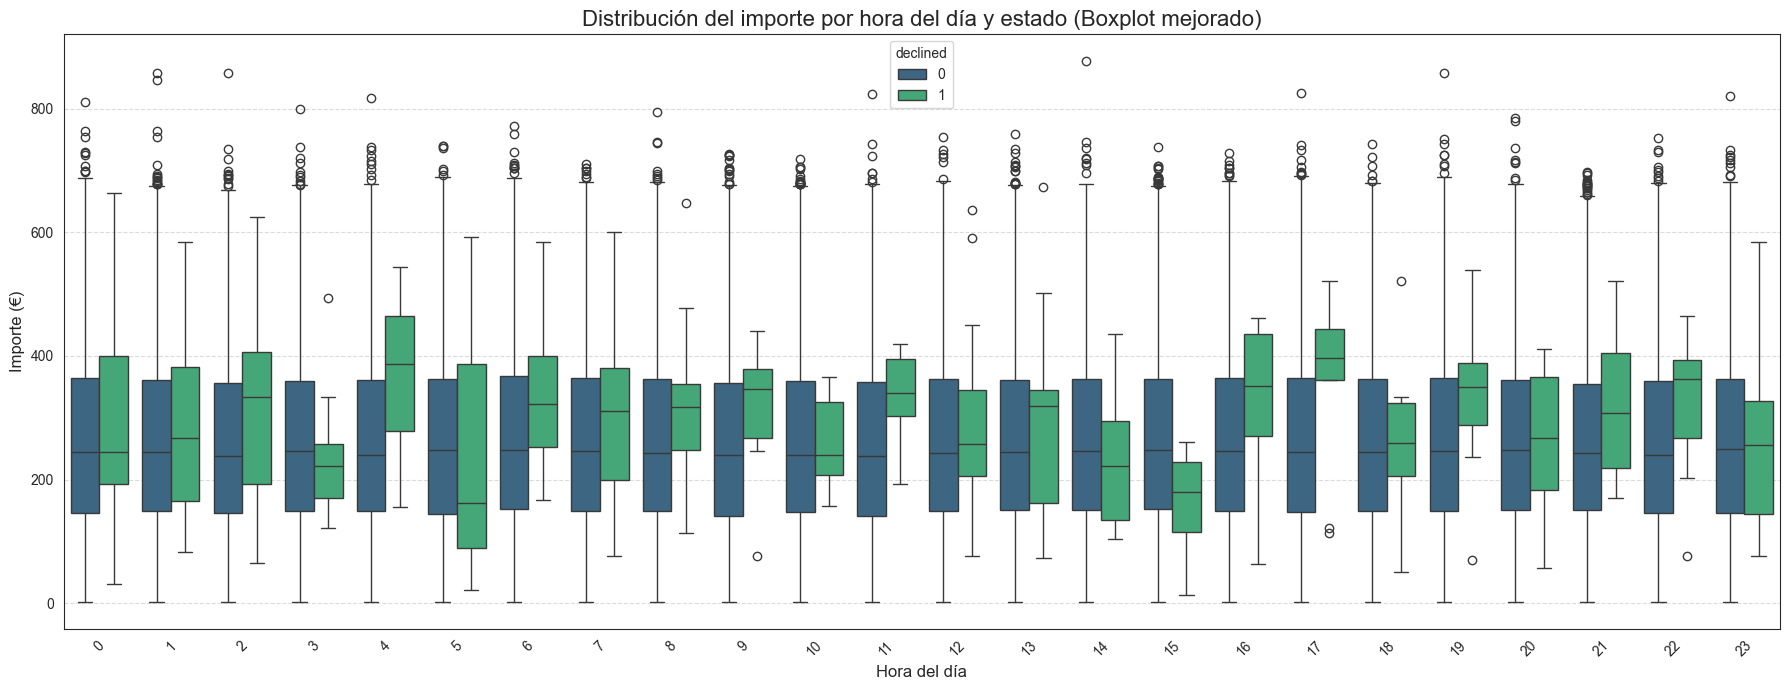

In [12]:
# Propuesta Gemini:

sns.set_style("white")
plt.figure(figsize=(18, 7))

sns.boxplot(
    data=df_transactions,
    x='hour',
    y='amount',
    hue='declined',
    palette='viridis' # Una paleta de colores diferente para mayor contraste
)

plt.title("Distribución del importe por hora del día y estado (Boxplot mejorado)", fontsize=16)
plt.xlabel("Hora del día", fontsize=12)
plt.ylabel("Importe (€)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7) # Añadir cuadrícula en el eje Y para facilitar la lectura
plt.xticks(rotation=45) # Rotar las etiquetas del eje X si se superponen
plt.tight_layout()
plt.show()

**Evaluación:**

El boxplot facilita mucho la interpretación, pues se pueden observar con mayor claridad la mediana, cuartiles y outliers, y se aprecia mejor la diferencia entre transacciones realizadas o declinadas. Me parece bastante mejor opción que el violinplot en este caso concreto donde tenemos 24 gráficos a evaluar.

***4. Distribución de la venta por día de la semana***


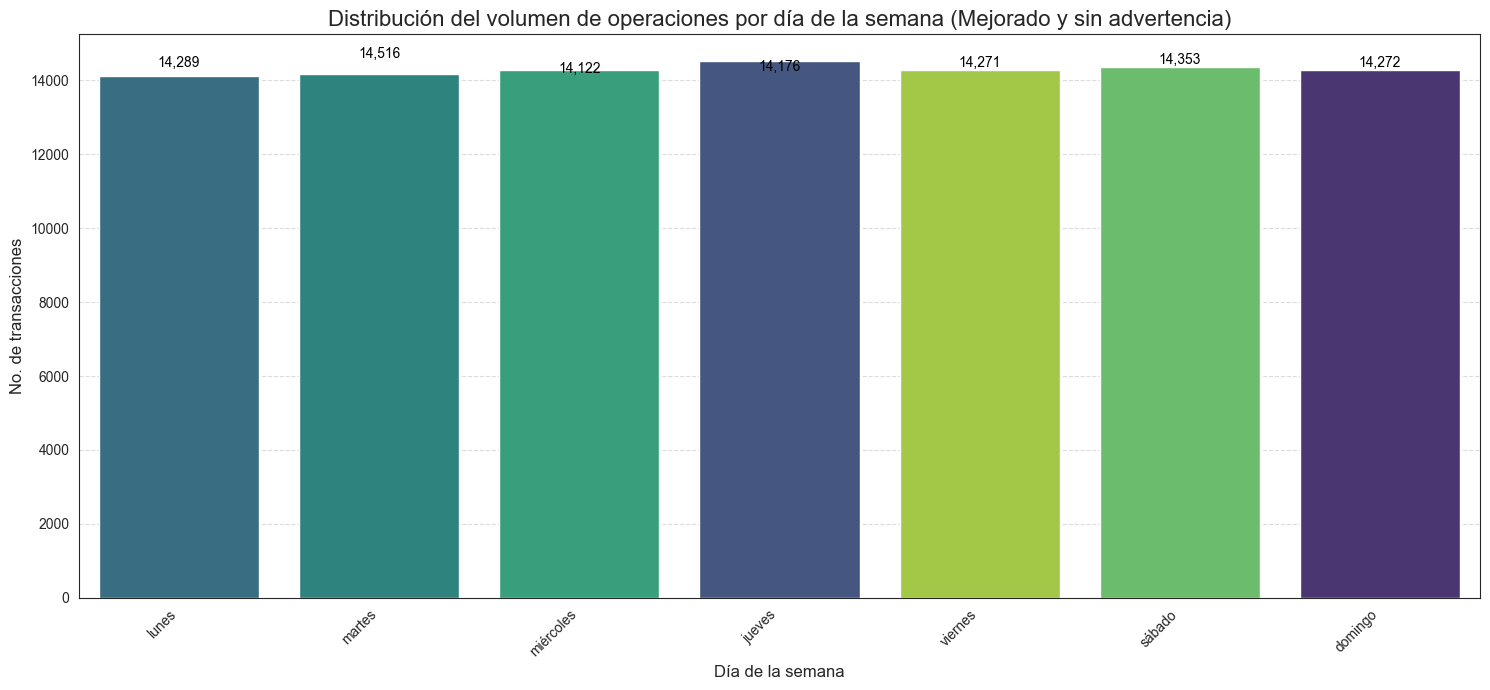

In [13]:
# Propuesta Gemini 1

sns.set_style("white")
plt.figure(figsize=(15, 7))

sns.barplot(
    x="timestamp",
    y="weekday_transactions_total",
    data=df_venta_semana,
    palette='viridis', # Usar una paleta de colores diferente para mayor contraste
    order=orden_semana, # Mantener el orden de los días de la semana
    hue="timestamp", # Asignar 'timestamp' a hue para evitar el FutureWarning
    legend=False # Desactivar la leyenda ya que hue se usa para el color de cada barra
)

plt.title("Distribución del volumen de operaciones por día de la semana (Mejorado y sin advertencia)", fontsize=16)
plt.xlabel("Día de la semana", fontsize=12)
plt.ylabel("No. de transacciones", fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotar las etiquetas del eje X si se superponen y alinear a la derecha

# Añadir etiquetas de valor a las barras
for index, row in df_venta_semana.iterrows():
    plt.text(index, row.weekday_transactions_total, f'{row.weekday_transactions_total:,}', color='black', ha="center", va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.7) # Añadir cuadrícula en el eje Y para facilitar la lectura
plt.tight_layout()
plt.show()

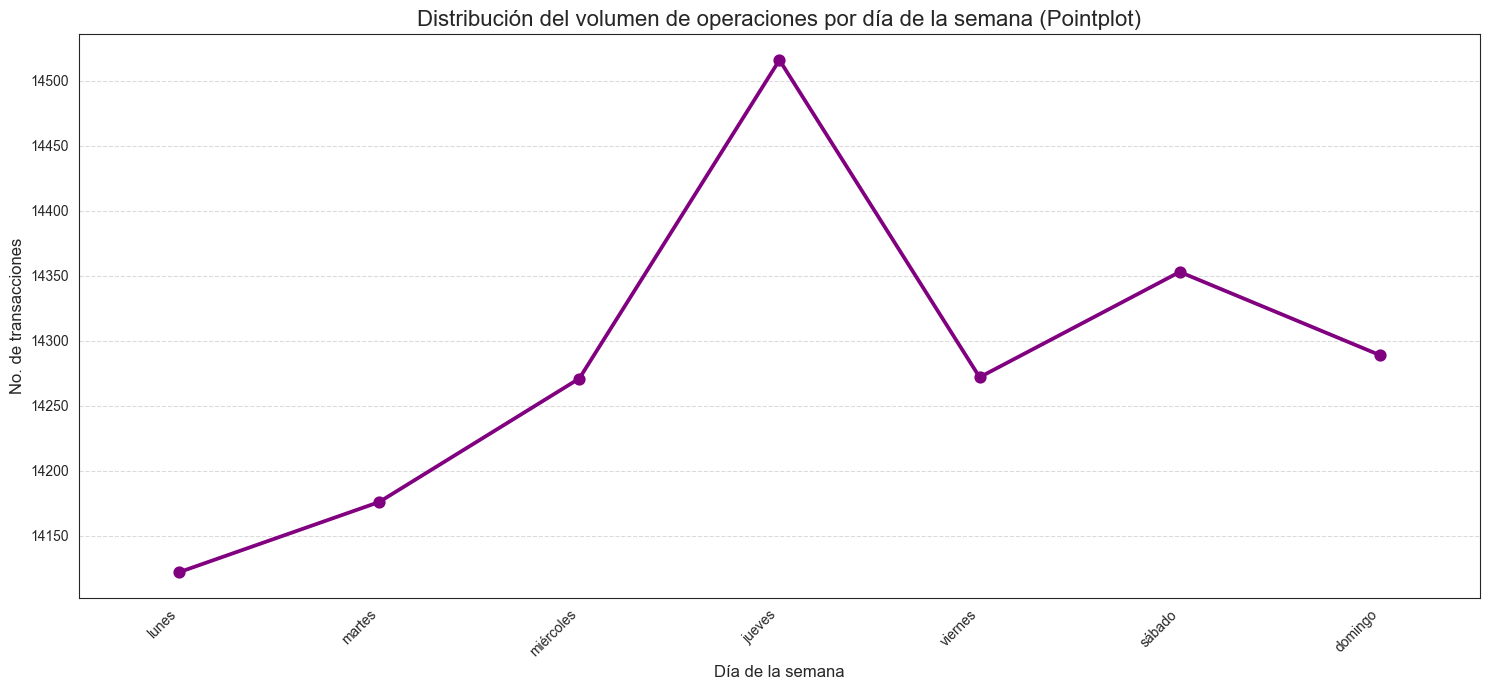

In [14]:
# Propuesta Gemini 2

sns.set_style("white")
plt.figure(figsize=(15, 7))

sns.pointplot(
    x="timestamp",
    y="weekday_transactions_total",
    data=df_venta_semana,
    order=orden_semana, # Mantener el orden de los días de la semana
    color='purple' # Un color para el punto y la línea
)

plt.title("Distribución del volumen de operaciones por día de la semana (Pointplot)", fontsize=16)
plt.xlabel("Día de la semana", fontsize=12)
plt.ylabel("No. de transacciones", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Evaluación:**

En este caso, Gemini nos propone primero el mismo barplot, pero con pequeñas modificaciones que mejoran legibilidad. Sin embargo, el tipo de gráfico no parece ideal pues las diferencias entre cada día son mínimas, casi imperceptibles en una gráfica de barras. Al solicitarle de nuevo, Gemini nos propone un pointplot (gráfico de línea), en el que se nota con mayor claridad el ascenso o caída del volumen entre días de la semana.

### Ex. 2: Preguntas analíticas complejas (con guía)

**Contexto:** Este ejercicio requiere combinar información de diferentes tablas del modelo para poder responder correctamente las preguntas.

Aquí sí que será necesario:
- Hacer merge entre tablas.
- Utilizar groupby, pivot_table, crosstab...
- Aplicar agregaciones, transformaciones intermedias y funciones.

Preguntas analíticas (con guía general):
- ¿Dependemos excesivamente de un número reducido de países de compañías vendedoras? Pasos orientativos:
    - Combinar la información de transacciones con la de compañías.
    - Agrupar la facturación por país.
    - Calcular la facturación total generada para cada país.
    - Ordenar los países de mayor a menor facturación.
    - Calcular el porcentaje acumulado sobre el total.
    - Visualizar.
- ¿Existe estacionalidad en las ventas? Pasos orientativos:
    - Trabajar con fechas de transacción.
    - Extraer la información temporal relevante (año y mes).
    - Calcular el volumen total de ventas (suma de amount) por año y mes.
    - Comparar patrones temporales con la comparación entre años. Crea una tabla tipo pivot.
    - Visualizar la evolución.
- Análisis de concentración y variabilidad (elige UNA opción)
    - Opción A - Producto (Sólo si dispones de la tabla de productos) ¿Qué productos generan más ingresos y con qué variabilidad? Pasos orientativos:
        - Combinar transacciones, la tabla puente y productos.
        - Calcular ingresos por producto con un groupby, sum y sort.
        - Selecciona los top N productos: 15 por ejemplo.
        - Escoger una visualización adecuada para analizar dispersión.
    - Opción B - Actividad de usuarios (Alternativa si no dispones de la tabla de productos) ¿Hay usuarios que han dejado de comprar recientemente? Pasos orientativos:
        - Identificar la última compra por usuario.
        - Calcular el tiempo desde la última compra.
        - Visualizar la distribución del tiempo desde la última compra.
- ¿Cómo varía la actividad de venta por franjas horarias a lo largo de los años? (patrones horarios). Pasos orientativos:
    - Crear franjas horarias a partir de la hora: crea una función y aplícala utilizando apply.
    - Construir una tabla agregada utilizando crosstab.
    - Visualizar con un heatmap.

Para cada pregunta:
- Describe brevemente los pasos seguidos.
- Muestra la visualización final.
- Interpreta qué implica para el negocio.

In [15]:
# 1. ¿Dependemos excesivamente de un número reducido de países de compañías vendedoras?
# Extraer la tabla de compañías:

df_companies = pd.read_sql("SELECT * FROM companies", conexion)
df_companies

/var/folders/ml/6tvhfsz115n38k7_180gd7n80000gn/T/ipykernel_75033/1906890630.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_companies = pd.read_sql("SELECT * FROM companies", conexion)


,company_id,company_name,phone,email,country,website
0,b-2222,Ac Fermentum Incorporated,06 85 56 52 33,donec.porttitor.tellus@yahoo.net,Germany,https://instagram.com/site\r
1,b-2226,Magna A Neque Industries,04 14 44 64 62,risus.donec.nibh@icloud.org,Australia,https://whatsapp.com/group/9\r
2,b-2230,Fusce Corp.,08 14 97 58 85,risus@protonmail.edu,United States,https://pinterest.com/sub/cars\r
3,b-2234,Convallis In Incorporated,06 66 57 29 50,mauris.ut@aol.couk,Germany,https://cnn.com/user/110\r
4,b-2238,Ante Iaculis Nec Foundation,08 23 04 99 53,sed.dictum.proin@outlook.ca,New Zealand,https://netflix.com/settings\r
...,...,...,...,...,...,...
95,b-2602,Placerat LLP,05 43 67 24 41,tellus.suspendisse@hotmail.org,Netherlands,https://zoom.us/sub\r
96,b-2606,Sed Est Corp.,04 58 02 37 91,tempor.bibendum@google.couk,Canada,https://instagram.com/sub/cars\r
97,b-2610,Egestas Nunc Sed Limited,06 01 02 70 47,vitae@hotmail.edu,Italy,https://walmart.com/one\r
98,b-2614,Rutrum Non Inc.,02 66 31 61 09,neque@protonmail.net,Germany,https://netflix.com/site\r


In [16]:
# Hacer merge de los 2 df:

df_trans_companies = df_transactions.merge(df_companies, on='company_id', how='inner')
df_trans_companies

,transaction_id,card_id,company_id,timestamp,hour,amount,declined,product_ids,user_id,lat,longitude,company_name,phone,email,country,website
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,7,395.43,0,"16, 26, 97, 87",4713,46.1999,1.43554,Eget Tincidunt Dui Institute,05 35 93 32 44,eget.laoreet@hotmail.org,Netherlands,https://wikipedia.org/user/110\r
1,00045D6B-ED2E-4F2F-8186-CEE074D875D0,CcS-6699,b-2390,2020-07-14 15:37:45,15,326.01,0,"30, 11, 16, 81",2118,29.7573,-95.37960,Neque Tellus Imperdiet Corp.,09 15 42 22 11,vestibulum.ante.ipsum@aol.edu,Ireland,https://whatsapp.com/sub/cars\r
2,000481C3-1C26-4FEF-83A0-4CD0EB004BBD,CcS-6696,b-2230,2017-09-04 19:44:53,19,161.60,0,72,2115,53.5489,-113.50300,Fusce Corp.,08 14 97 58 85,risus@protonmail.edu,United States,https://pinterest.com/sub/cars\r
3,00051AA4-9CBE-4268-B070-C38062A1B3E2,CcS-7606,b-2266,2017-01-05 18:19:25,18,148.91,0,18,3025,52.2084,5.69081,Mus Aenean Eget Foundation,06 25 15 52 43,mi.duis@hotmail.net,Sweden,https://instagram.com/group/9\r
4,0008A312-EDFE-4A4F-BC99-E9C92EC3CA4D,CcU-3358,b-2598,2023-09-23 04:51:43,4,294.59,0,"35, 33, 19",215,53.5535,-113.49900,Aliquam Iaculis Lacus Corp.,04 43 07 91 26,dictum@aol.org,Belgium,https://pinterest.com/one\r
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99994,FFF9E3CE-234E-408C-A8EF-F9CAD577224A,CcS-5010,b-2234,2022-12-17 20:57:55,20,247.39,0,"20, 42, 54, 46",429,52.5223,13.40490,Convallis In Incorporated,06 66 57 29 50,mauris.ut@aol.couk,Germany,https://cnn.com/user/110\r
99995,FFFB270D-F53A-4D5D-9666-E5307C53CC84,CcS-7655,b-2522,2024-05-13 03:42:03,3,349.13,0,"30, 87, 5, 66",3074,39.0271,-8.10523,Viverra Donec Foundation,03 33 12 32 73,dictum.eu@outlook.net,United Kingdom,https://nytimes.com/site\r
99996,FFFC9E8D-27C7-4ADE-98F2-7533EF4DF126,CcS-5589,b-2302,2019-10-30 02:31:37,2,234.22,0,"16, 49",1008,59.3327,18.07530,Nunc Interdum Incorporated,05 18 15 48 13,non@outlook.com,Germany,https://wikipedia.org/en-us\r
99997,FFFCF76D-ECF0-4985-A2D0-B2A7B75998FC,CcS-5261,b-2250,2023-06-17 19:10:30,19,148.91,0,18,680,52.0635,4.30862,Amet Nulla Donec Corporation,07 15 25 14 74,mattis.integer.eu@protonmail.net,Italy,https://netflix.com/sub/cars\r


In [17]:
# Agrupar por país, ordenar y calcular porcentaje del total

df_bill_country = df_trans_companies.groupby('country').agg(total_billing_country=('amount', 'sum'))
df_bill_country = df_bill_country.sort_values(by='total_billing_country', ascending=False).reset_index()
total_all_countries = df_bill_country['total_billing_country'].sum()
df_bill_country['percentage'] = round(df_bill_country['total_billing_country'] / total_all_countries * 100, 2)
df_bill_country_top5_percentage = round(df_bill_country['percentage'].head(5).sum(),2)
print(f'Porcentaje del total para los 5 países con mayor facturación: {df_bill_country_top5_percentage} %')
df_bill_country

Porcentaje del total para los 5 países con mayor facturación: 72.1 %


,country,total_billing_country,percentage
0,Sweden,4250917.23,16.41
1,Netherlands,3890755.90,15.02
2,United Kingdom,3537120.34,13.66
3,Italy,3530071.81,13.63
4,Germany,3466842.93,13.38
5,France,1221902.17,4.72
6,United States,1069450.71,4.13
7,Belgium,922131.39,3.56
8,Norway,785907.27,3.03
9,Ireland,693054.42,2.68


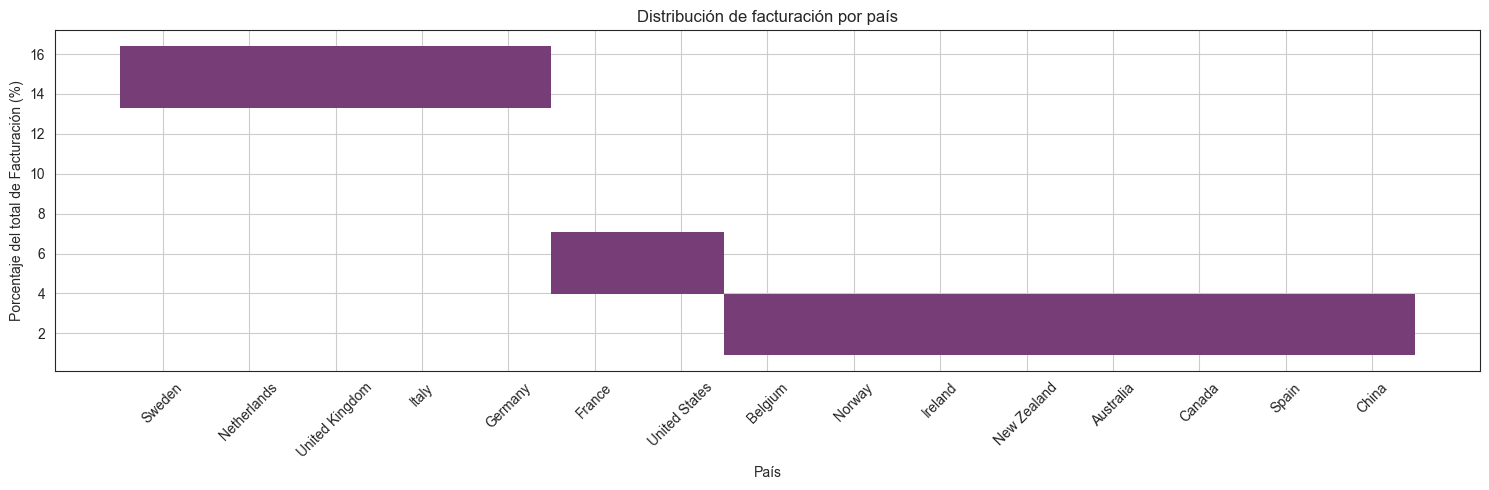

In [18]:
# Visualización de histograma:

sns.set_style("white")
plt.figure(figsize=(15,5))
plt.title("Distribución de facturación por país")
sns.histplot(x=df_bill_country['country'], y=df_bill_country['percentage'], color='purple')
plt.grid(True)
plt.xlabel("País")
plt.ylabel("Porcentaje del total de Facturación (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

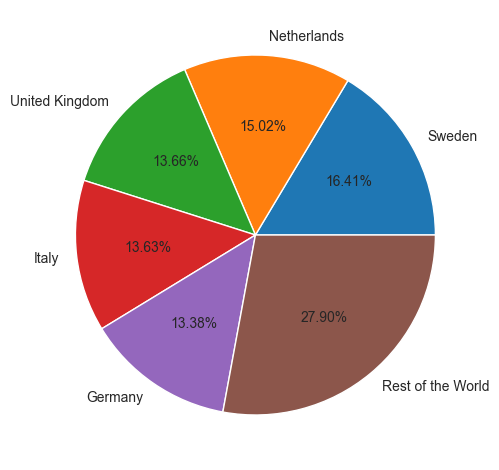

In [19]:
# Esto lo podemos graficar también con un piechart, pero en lugar de ver todos los países, sólo compararemos al top 5 con el resto.

facturacion_pais_top5 = df_bill_country.nlargest(5, 'total_billing_country')
facturacion_pais_resto = df_bill_country.nsmallest(len(df_bill_country['total_billing_country']) - 5, 'total_billing_country')
facturacion_resto = facturacion_pais_resto['total_billing_country'].sum()
facturacion_pais_resto = pd.DataFrame([{'country':'Rest of the World', 'total_billing_country':facturacion_resto}])
resultado = pd.concat([facturacion_pais_top5, facturacion_pais_resto], ignore_index=True)

sns.set_style("white")
plt.Figure(figsize=(8,8))
plt.pie(resultado['total_billing_country'], labels=resultado['country'], autopct='%1.2f%%')
plt.tight_layout()
plt.show()

***Interpretación:***

- Dependemos excesivamente de las ventas de 5 países (Suecia, Países Bajos, Reino Unido, Italia y Alemania), pues concentran el 72.10 % del negocio, cada uno con un porcentaje entre el 13 y el 17% aproximadamente.
- Si bien el piechart es un gráfico que dificulta representar con exactitud la diferencia entre las categorías, en este caso la idea es que muestre como entre 5 países tienen casi 3/4 partes del negocio.

In [20]:
# 2. ¿Existe estacionalidad en las ventas?
# Primero exploramos el dataframe haciendo agrupaciones, los valores deberían coincidir con la pivot table.

# Dataframe agrupado por año y mes en una sola columna

df_estacionalidad_año_mes = df_transactions.groupby(df_transactions['timestamp'].dt.strftime('%Y-%m')).agg(year_amount_total=('amount', 'sum')).reset_index()
df_estacionalidad_año_mes


,timestamp,year_amount_total
0,2015-01,208460.24
1,2015-02,211179.56
2,2015-03,221488.19
3,2015-04,214675.51
4,2015-05,215691.13
...,...,...
115,2024-08,214924.40
116,2024-09,212523.25
117,2024-10,217337.57
118,2024-11,212989.12


In [21]:
# Para convertirlo en una tabla pivot, primero extraemos el mes y el año de la columna timestamp para formar nuevas columnas

df_transactions_dates = df_transactions[['transaction_id', 'timestamp', 'amount']].copy()
df_transactions_dates['month'] = df_transactions_dates['timestamp'].dt.month_name(locale='es_ES.UTF-8')
df_transactions_dates['year'] = df_transactions_dates['timestamp'].dt.year
col_amount = df_transactions_dates.pop('amount')
indice_year = df_transactions_dates.columns.get_loc('year')
df_transactions_dates.insert(indice_year +1, 'amount', col_amount)
df_transactions_dates

,transaction_id,timestamp,month,year,amount
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,2024-08-28 07:16:46,Agosto,2024,395.43
1,00045D6B-ED2E-4F2F-8186-CEE074D875D0,2020-07-14 15:37:45,Julio,2020,326.01
2,000481C3-1C26-4FEF-83A0-4CD0EB004BBD,2017-09-04 19:44:53,Septiembre,2017,161.60
3,00051AA4-9CBE-4268-B070-C38062A1B3E2,2017-01-05 18:19:25,Enero,2017,148.91
4,0008A312-EDFE-4A4F-BC99-E9C92EC3CA4D,2023-09-23 04:51:43,Septiembre,2023,294.59
...,...,...,...,...,...
99994,FFF9E3CE-234E-408C-A8EF-F9CAD577224A,2022-12-17 20:57:55,Diciembre,2022,247.39
99995,FFFB270D-F53A-4D5D-9666-E5307C53CC84,2024-05-13 03:42:03,Mayo,2024,349.13
99996,FFFC9E8D-27C7-4ADE-98F2-7533EF4DF126,2019-10-30 02:31:37,Octubre,2019,234.22
99997,FFFCF76D-ECF0-4985-A2D0-B2A7B75998FC,2023-06-17 19:10:30,Junio,2023,148.91


In [22]:
# Transformamos el df en una tabla pivot y reordenamos las columnas de los meses cronológicamente

pt_transactions_dates = round(pd.pivot_table(
    data= df_transactions_dates,
    values= 'amount',
    index= 'year',
    columns= 'month',
    aggfunc= 'sum'
),2)

orden_meses = ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio', 'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre']
pt_transactions_dates = pt_transactions_dates[orden_meses]

pt_transactions_dates

month,Enero,Febrero,Marzo,Abril,Mayo,Junio,Julio,Agosto,Septiembre,Octubre,Noviembre,Diciembre
year,,,,,,,,,,,,
2015,208460.24,211179.56,221488.19,214675.51,215691.13,207759.31,218137.92,214170.06,204305.09,207329.31,206086.20,215907.55
2016,212357.82,214708.37,215368.86,210019.54,208713.77,208534.96,213505.12,212853.75,217441.50,213392.79,212567.32,216725.29
2017,209339.50,215198.48,208608.27,218995.78,204784.10,216287.92,218788.44,209566.97,211802.81,207924.36,219837.77,230320.82
2018,214646.54,209918.88,207377.32,205562.05,210126.23,217047.48,208823.33,207536.16,214016.87,219609.95,218591.71,213640.31
2019,210813.99,222423.06,243592.36,212679.25,208853.84,220443.02,211037.50,215470.42,210429.63,213913.65,209583.99,231577.72
2020,219397.63,211273.68,227262.89,213422.08,216073.84,212762.98,217751.47,210762.54,231158.60,221645.25,201522.40,224453.23
2021,232197.63,219685.97,220554.92,227276.44,206925.66,211362.56,227301.53,214414.67,222361.90,227128.13,217622.12,222631.39
2022,212873.78,202945.83,238293.06,209160.91,236573.86,233213.16,211532.08,220744.50,228802.26,218577.07,210127.87,217191.26
2023,218300.84,214480.16,212086.80,214159.74,225828.47,210788.42,215904.46,214257.04,213400.04,213194.28,212763.80,215360.53


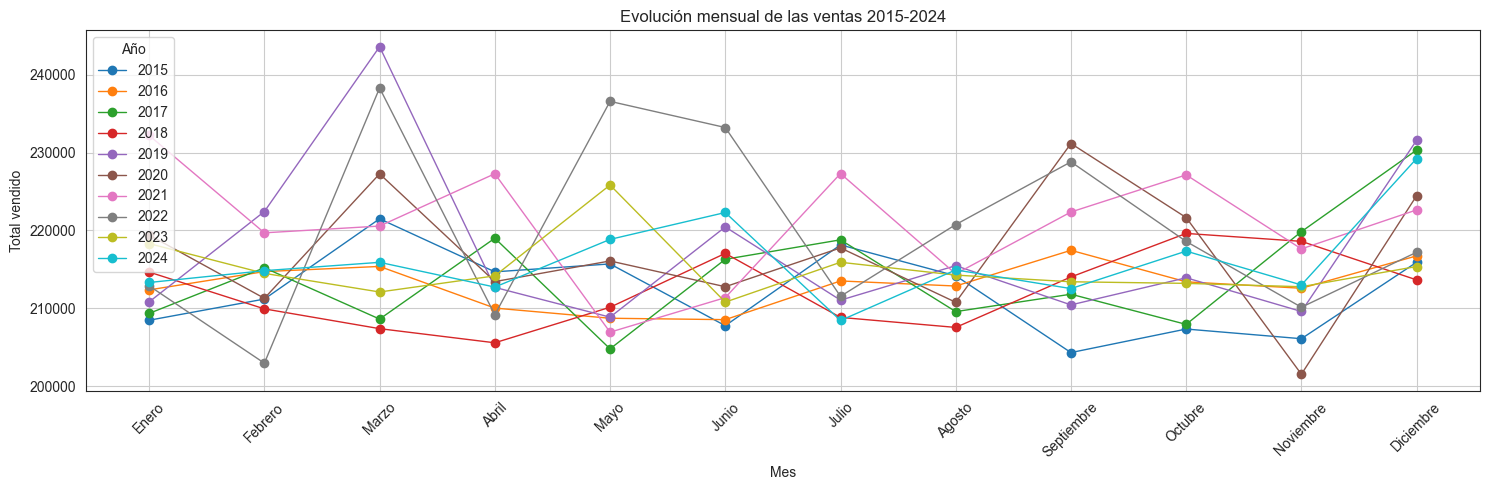

In [23]:
# Gráfico lineal con plot, usamos un bucle para generar una línea para cada año:

sns.set_style("white")
plt.figure(figsize=(15,5))
for año, fila in pt_transactions_dates.iterrows():
    plt.plot(fila.index, fila.values, linewidth=1, marker='o', label= año)
plt.title("Evolución mensual de las ventas 2015-2024")
plt.xlabel('Mes')
plt.ylabel('Total vendido')
plt.xticks(rotation=45)
plt.legend(title='Año')
plt.grid()
plt.tight_layout()
plt.show()

***Interpretación del gráfico:***
*Entendiendo la estacionalidad como patrones que se repiten en el tiempo en momentos específicos, podemos apreciar lo siguiente:*
- El pico de ventas se alcanzó en marzo de 2019, mientras que la mayor caída se dio en noviembre de 2020.
- Para la mayoría de los años, vemos caídas en agosto y noviembre.
- Los incrementos en ventas suelen darse en marzo y diciembre.
- Para el resto de meses, no vemos un patrón de estacionalidad muy claro, pues varía a lo largo de los años en forma más o menos proporcionada entre incrementos y caídas.

Al estar evaluando un periodo de 10 años, podría resultar más fácil para el análisis separarlo en 2 bloques de 5 años. O bien, elegir un heatmap para visualizar, donde se puede ver cada año en una fila.

In [24]:
# 3. Análisis de concentración y variabilidad

# Importar la tabla de productos:

df_products = pd.read_sql("SELECT * FROM products", conexion)
df_products.rename(columns={'id': 'product_id'}, inplace=True)
df_products

/var/folders/ml/6tvhfsz115n38k7_180gd7n80000gn/T/ipykernel_75033/1752639014.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_products = pd.read_sql("SELECT * FROM products", conexion)


,product_id,product_name,price,colour,weight,warehouse_id
0,1,Direwolf Stannis,$161.11,#7c7c7c,1.0,WH-4
1,10,Karstark Dorne,$119.52,#f4f4f4,2.4,WH--5
2,100,south duel,$40.43,#6d6d6d,3.0,WH--95
3,11,Karstark Dorne,$49.70,#141414,2.7,WH--6
4,12,duel Direwolf,$181.60,#a8a8a8,2.1,WH--7
...,...,...,...,...,...,...
95,95,riverlands north Direwolf,$6.90,#c1c1c1,2.7,WH--90
96,96,dooku solo,$20.92,#282828,2.1,WH--91
97,97,jinn Winterfell,$65.25,#bababa,1.0,WH--92
98,98,Direwolf Littlefinger,$38.33,#bababa,2.0,WH--93


In [25]:
# Convertir la columna product_ids en un array y explotarlo

df_transactions['product_id'] = df_transactions['product_ids'].str.split(', ')
col_prod_id = df_transactions.pop('product_id')
indice_prod_ids = df_transactions.columns.get_loc('product_ids')
df_transactions.insert(indice_prod_ids +1, 'product_id', col_prod_id)
df_transactions_exp = df_transactions.explode('product_id')
df_transactions_exp

,transaction_id,card_id,company_id,timestamp,hour,amount,declined,product_ids,product_id,user_id,lat,longitude
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,7,395.43,0,"16, 26, 97, 87",16,4713,46.1999,1.43554
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,7,395.43,0,"16, 26, 97, 87",26,4713,46.1999,1.43554
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,7,395.43,0,"16, 26, 97, 87",97,4713,46.1999,1.43554
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,7,395.43,0,"16, 26, 97, 87",87,4713,46.1999,1.43554
1,00045D6B-ED2E-4F2F-8186-CEE074D875D0,CcS-6699,b-2390,2020-07-14 15:37:45,15,326.01,0,"30, 11, 16, 81",30,2118,29.7573,-95.37960
...,...,...,...,...,...,...,...,...,...,...,...,...
99996,FFFC9E8D-27C7-4ADE-98F2-7533EF4DF126,CcS-5589,b-2302,2019-10-30 02:31:37,2,234.22,0,"16, 49",16,1008,59.3327,18.07530
99996,FFFC9E8D-27C7-4ADE-98F2-7533EF4DF126,CcS-5589,b-2302,2019-10-30 02:31:37,2,234.22,0,"16, 49",49,1008,59.3327,18.07530
99997,FFFCF76D-ECF0-4985-A2D0-B2A7B75998FC,CcS-5261,b-2250,2023-06-17 19:10:30,19,148.91,0,18,18,680,52.0635,4.30862
99998,FFFD31D6-9495-47CE-B54A-7DB8E1CC274B,CcS-5684,b-2450,2021-08-05 12:26:24,12,74.54,0,"48, 26",48,1103,55.6384,-3.61660


In [26]:
# Importar la tabla puente
df_transactions_products = pd.read_sql("SELECT * FROM transactions_products", conexion)
df_transactions_products

# NOTA: Habiendo explotado los product_ids de la tabla transactions, esta tabla puente no es necesaria para el análisis, pues además incluye transacciones declinadas.

/var/folders/ml/6tvhfsz115n38k7_180gd7n80000gn/T/ipykernel_75033/1913119589.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_transactions_products = pd.read_sql("SELECT * FROM transactions_products", conexion)


,transaction_id,product_id
0,001A60EA-DC9C-4E5A-9460-6628B100E7E1,1
1,0032F0BB-BBE6-4AA5-B5EE-EEAD533C0C48,1
2,00342381-503D-422D-85AB-F2D4FFAAD4C7,1
3,004C0A80-E537-46D8-BE44-343D2176DF15,1
4,004D1DB5-B2CB-4460-98B6-31C42CA96E5F,1
...,...,...
253383,FF91BCB9-4D5D-4409-9CAF-014774C917E5,99
253384,FFAB960B-2F67-488D-8009-F7E607F196C6,99
253385,FFD56B81-4495-4358-9487-F83B9FD490C6,99
253386,FFE23DC5-048A-478D-AA8E-F8D0228B7D16,99


In [27]:
# Hacemos merge para formar un df nuevo, nos quedamos sólo con las columnas más relevantes para este análisis y omitimos los registros que hayan sido declinados.
# Eliminamos símbolos de la columna price y la convertimos a numérica

df_analisis_producto = df_transactions_exp.merge(df_products, on='product_id', how='inner')
df_analisis_producto = df_analisis_producto[['transaction_id', 'company_id', 'timestamp', 'hour', 'amount', 'declined', 'user_id', 'product_id', 'product_name', 'price']]
df_analisis_producto = df_analisis_producto.loc[df_analisis_producto['declined'] == 0]
df_analisis_producto['price'] = df_analisis_producto['price'].str.strip('$')
df_analisis_producto['price'] = pd.to_numeric(df_analisis_producto['price'])
df_analisis_producto

,transaction_id,company_id,timestamp,hour,amount,declined,user_id,product_id,product_name,price
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,b-2458,2024-08-28 07:16:46,7,395.43,0,4713,16,the duel warden,180.91
1,00043A49-2949-494B-A5DD-A5BAE3BB19DD,b-2458,2024-08-28 07:16:46,7,395.43,0,4713,26,Stark Karstark,53.01
2,00043A49-2949-494B-A5DD-A5BAE3BB19DD,b-2458,2024-08-28 07:16:46,7,395.43,0,4713,97,jinn Winterfell,65.25
3,00043A49-2949-494B-A5DD-A5BAE3BB19DD,b-2458,2024-08-28 07:16:46,7,395.43,0,4713,87,sith Jade,96.26
4,00045D6B-ED2E-4F2F-8186-CEE074D875D0,b-2390,2020-07-14 15:37:45,15,326.01,0,2118,30,Karstark warden,79.53
...,...,...,...,...,...,...,...,...,...,...
253383,FFFC9E8D-27C7-4ADE-98F2-7533EF4DF126,b-2302,2019-10-30 02:31:37,2,234.22,0,1008,16,the duel warden,180.91
253384,FFFC9E8D-27C7-4ADE-98F2-7533EF4DF126,b-2302,2019-10-30 02:31:37,2,234.22,0,1008,49,the giantsblood maester,53.31
253385,FFFCF76D-ECF0-4985-A2D0-B2A7B75998FC,b-2250,2023-06-17 19:10:30,19,148.91,0,680,18,Karstark warden,148.91
253386,FFFD31D6-9495-47CE-B54A-7DB8E1CC274B,b-2450,2021-08-05 12:26:24,12,74.54,0,1103,48,rock Renly in,21.53


In [28]:
# Hacemos agrupaciones para encontrar los productos que más ingresos han generado, ordenamos y limitamos al top 15:

df_productos_pedidos = round(df_analisis_producto.groupby(['transaction_id', 'product_name', 'product_id']).agg(price=('price', 'sum'), product_variability=('product_id', 'count')),2).reset_index()
df_productos_resumen = df_productos_pedidos.groupby(['product_name', 'price', 'product_variability']).agg(total_transactions=('transaction_id', 'nunique')).reset_index()
df_productos_resumen['total_earnings_per_product'] = round(df_productos_resumen['price'] * df_productos_resumen['total_transactions'],2)
df_productos_top15 = df_productos_resumen.sort_values(by='total_earnings_per_product', ascending=False).head(15)
df_productos_top15

,product_name,price,product_variability,total_transactions,total_earnings_per_product
97,warden,196.65,1,2570,505390.50
1,Direwolf,195.62,1,2562,501178.44
42,Winterfell,195.94,1,2541,497883.54
27,Stannis warden,194.29,1,2524,490387.96
23,Littlefinger Tarly Stark,192.60,1,2529,487085.40
93,the duel,188.94,1,2542,480285.48
31,Stark kingsblood,189.21,1,2514,475673.94
11,Jade tatooine dooku,188.58,1,2515,474278.70
94,the duel warden,180.91,1,2602,470727.82
53,duel Direwolf,181.60,1,2548,462716.80


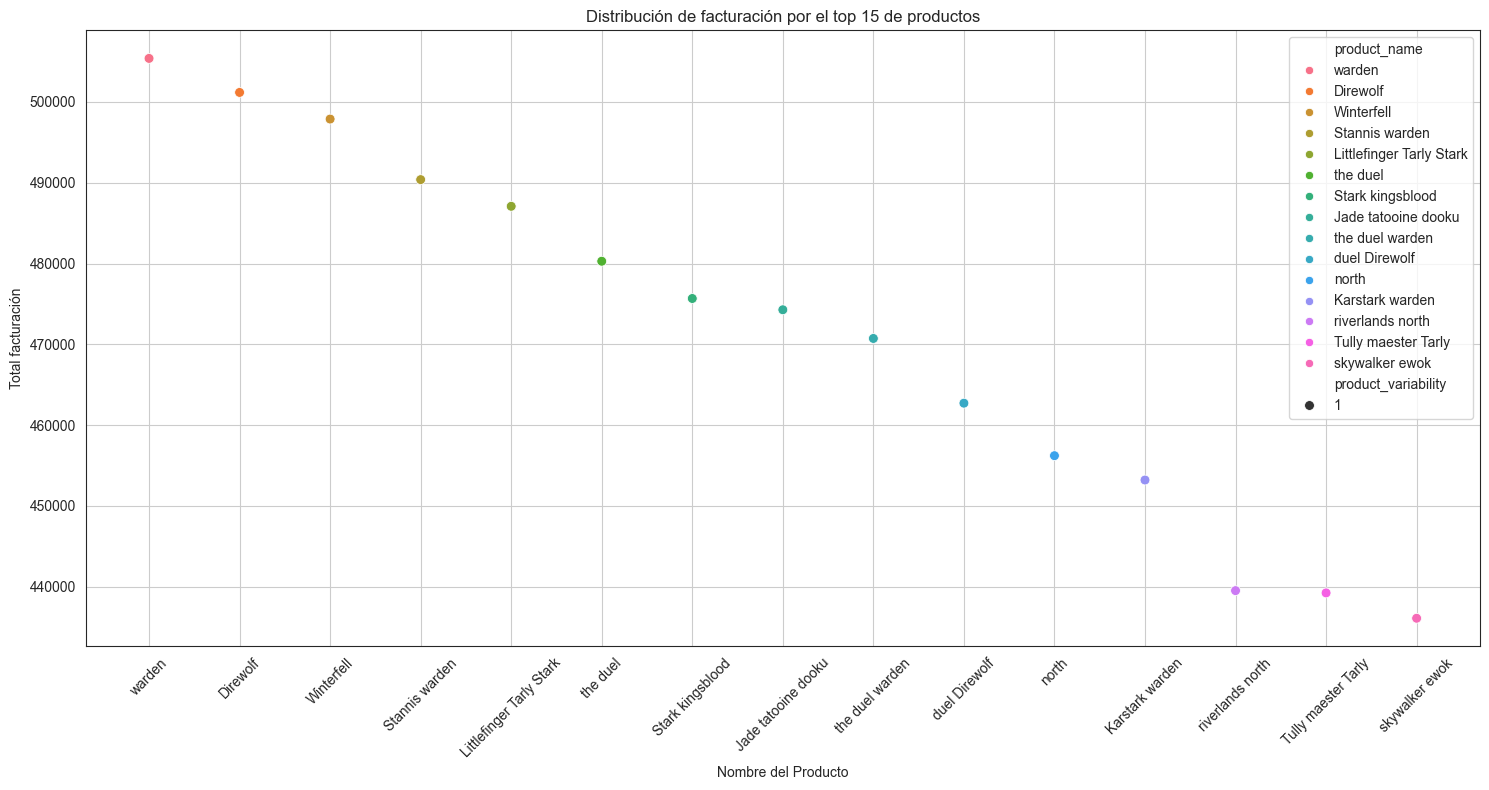

In [29]:
# Visualización del scatterplot

sns.set_style("white")
plt.figure(figsize=(15,8))
sns.scatterplot(
    data=df_productos_top15,
    x='product_name',
    y='total_earnings_per_product',
    hue='product_name',
    size='product_variability',
    sizes=(50,200)
)
plt.title("Distribución de facturación por el top 15 de productos")
plt.xlabel('Nombre del Producto')
plt.ylabel('Total facturación')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

In [30]:
print(f'Mínimo de transacciones totales: {df_productos_resumen['total_transactions'].min()}')
print(f'Máximo de transacciones totales: {df_productos_resumen['total_transactions'].max()}')
print(f'Media de transacciones totales: {df_productos_resumen["total_transactions"].mean()}')

Mínimo de transacciones totales: 2405
Máximo de transacciones totales: 2642
Media de transacciones totales: 2526.9


In [31]:
print(f"Mínimo de ingreso total por producto: {df_productos_resumen['total_earnings_per_product'].min()}")
print(f"Máximo de ingreso total por producto: {df_productos_resumen['total_earnings_per_product'].max()}")
print(f"Media de ingreso total por producto: {df_productos_resumen['total_earnings_per_product'].mean()}")

Mínimo de ingreso total por producto: 5488.68
Máximo de ingreso total por producto: 505390.5
Media de ingreso total por producto: 258302.2879


***Interpretación:***
- El producto warden fue el que más ingresos generó, superando los 500.000 €.
- En general, el top 15 supera por mucho la media general, que es aproximadamente la mitad de lo generado por nuestro producto ganador.
- Los productos presentan una variabilidad de 1. Es decir, cada pedido incluye como máximo 1 unidad de cada producto.
- En general los productos se han vendido de forma similar, pues la media de transacciones es de 2526, con los máximos y mínimos bastante cerca.

In [32]:
# 4. ¿Cómo varía la actividad de venta por franjas horarias a lo largo de los años? (patrones horarios)

# Creamos una función que devuelve una franja horaria, siguiendo esta escala y aprovechando que en un ejercicio anterior habíamos extraído la hora del timestamp:
# De 5:00 AM a 12:59: morning
# De 13:00 a 20:59: noon
# De 21:00 a 4:59: night

def franjas_horarias(hora):
    if 5 <= hora < 13:
        return 'morning'
    elif 13 <= hora < 21:
        return 'noon'
    else:
        return 'night'

df_analisis_producto['timeslot'] = df_analisis_producto['hour'].apply(franjas_horarias)
col_timeslot = df_analisis_producto.pop('timeslot')
indice_hora = df_analisis_producto.columns.get_loc('hour')
df_analisis_producto.insert(indice_hora +1, 'timeslot', col_timeslot)
df_analisis_producto

,transaction_id,company_id,timestamp,hour,timeslot,amount,declined,user_id,product_id,product_name,price
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,b-2458,2024-08-28 07:16:46,7,morning,395.43,0,4713,16,the duel warden,180.91
1,00043A49-2949-494B-A5DD-A5BAE3BB19DD,b-2458,2024-08-28 07:16:46,7,morning,395.43,0,4713,26,Stark Karstark,53.01
2,00043A49-2949-494B-A5DD-A5BAE3BB19DD,b-2458,2024-08-28 07:16:46,7,morning,395.43,0,4713,97,jinn Winterfell,65.25
3,00043A49-2949-494B-A5DD-A5BAE3BB19DD,b-2458,2024-08-28 07:16:46,7,morning,395.43,0,4713,87,sith Jade,96.26
4,00045D6B-ED2E-4F2F-8186-CEE074D875D0,b-2390,2020-07-14 15:37:45,15,noon,326.01,0,2118,30,Karstark warden,79.53
...,...,...,...,...,...,...,...,...,...,...,...
253383,FFFC9E8D-27C7-4ADE-98F2-7533EF4DF126,b-2302,2019-10-30 02:31:37,2,night,234.22,0,1008,16,the duel warden,180.91
253384,FFFC9E8D-27C7-4ADE-98F2-7533EF4DF126,b-2302,2019-10-30 02:31:37,2,night,234.22,0,1008,49,the giantsblood maester,53.31
253385,FFFCF76D-ECF0-4985-A2D0-B2A7B75998FC,b-2250,2023-06-17 19:10:30,19,noon,148.91,0,680,18,Karstark warden,148.91
253386,FFFD31D6-9495-47CE-B54A-7DB8E1CC274B,b-2450,2021-08-05 12:26:24,12,morning,74.54,0,1103,48,rock Renly in,21.53


In [33]:
# Extraer el año del timestamp

df_analisis_producto['year'] = df_analisis_producto['timestamp'].dt.year
col_year = df_analisis_producto.pop('year')
indice_hora = df_analisis_producto.columns.get_loc('hour')
df_analisis_producto.insert(indice_hora, 'year', col_year)
df_analisis_producto

,transaction_id,company_id,timestamp,year,hour,timeslot,amount,declined,user_id,product_id,product_name,price
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,b-2458,2024-08-28 07:16:46,2024,7,morning,395.43,0,4713,16,the duel warden,180.91
1,00043A49-2949-494B-A5DD-A5BAE3BB19DD,b-2458,2024-08-28 07:16:46,2024,7,morning,395.43,0,4713,26,Stark Karstark,53.01
2,00043A49-2949-494B-A5DD-A5BAE3BB19DD,b-2458,2024-08-28 07:16:46,2024,7,morning,395.43,0,4713,97,jinn Winterfell,65.25
3,00043A49-2949-494B-A5DD-A5BAE3BB19DD,b-2458,2024-08-28 07:16:46,2024,7,morning,395.43,0,4713,87,sith Jade,96.26
4,00045D6B-ED2E-4F2F-8186-CEE074D875D0,b-2390,2020-07-14 15:37:45,2020,15,noon,326.01,0,2118,30,Karstark warden,79.53
...,...,...,...,...,...,...,...,...,...,...,...,...
253383,FFFC9E8D-27C7-4ADE-98F2-7533EF4DF126,b-2302,2019-10-30 02:31:37,2019,2,night,234.22,0,1008,16,the duel warden,180.91
253384,FFFC9E8D-27C7-4ADE-98F2-7533EF4DF126,b-2302,2019-10-30 02:31:37,2019,2,night,234.22,0,1008,49,the giantsblood maester,53.31
253385,FFFCF76D-ECF0-4985-A2D0-B2A7B75998FC,b-2250,2023-06-17 19:10:30,2023,19,noon,148.91,0,680,18,Karstark warden,148.91
253386,FFFD31D6-9495-47CE-B54A-7DB8E1CC274B,b-2450,2021-08-05 12:26:24,2021,12,morning,74.54,0,1103,48,rock Renly in,21.53


In [34]:
# Hacemos la tabla agregada con crosstab:

df_transactions_cross = pd.crosstab(
    index=df_analisis_producto['year'],
    columns=df_analisis_producto['timeslot']
)

orden_trans_cross = ['morning', 'noon', 'night']
df_transactions_cross = df_transactions_cross[orden_trans_cross]
df_transactions_cross

timeslot,morning,noon,night
year,,,
2015,8373,8410,8135
2016,8251,8431,8176
2017,8396,8178,8330
2018,8244,8328,8305
2019,8548,8444,8353
2020,8607,8290,8703
2021,8805,8580,8556
2022,8362,8671,8702
2023,8310,8496,8456


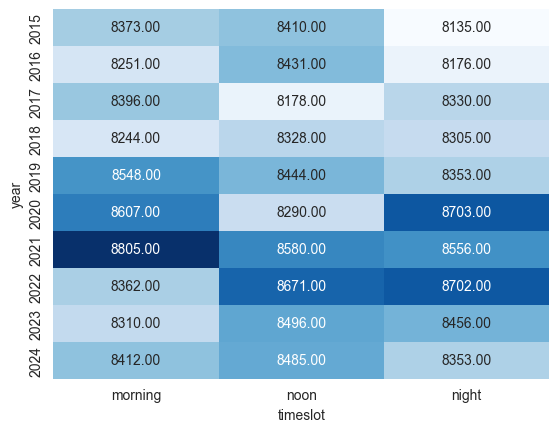

In [35]:
# Y generamos un heatmap
heatmap_timeslot = sns.heatmap(
    data=df_transactions_cross,
    cmap='Blues',
    fmt='.2f',
    annot=True,
    cbar=False
)

***Interpretación:***
*Después de desplegar el mapa de calor, observamos lo siguiente:*

- En la franja de mañana durante el año 2021 se alcanzó el máximo número de operaciones (8805).
- Por otro lado, el mínimo se tuvo durante la franja nocturna, durante el 2015 (8135).
- En los últimos 2 años del df, en la franja de tardes es en la que más operaciones se han realizado.
- No apreciamos un patrón claro a lo largo de los años: en cada año, el número de operaciones en las distintas franjas varía, sin que una predomine o por el contrario, suela tener menos operaciones.
- Podría ser interesante hacer más franjas horarias (bloques de 4-6 horas?), donde quizás se puedan observar patrones definidos ya que en 8 horas la conducta del consumidor puede variar mucho.

## Nivel 2 – Análisis relacional y patrones avanzados

### Ex. 1: Análisis de productos y captación de usuarios
**Objetivo:** Analizar el rendimiento de los productos combinando ingresos, estabilidad y capacidad de captación de nuevos usuarios, con el objetivo de detectar posibles riesgos de negocio asociados a concentración excesiva de ingresos, dependencia de usuarios recurrentes y falta de crecimiento en base de usuarios.

Los productos que generan más ingresos también impulsan el crecimiento del negocio mediante la captación de nuevos usuarios, o bien el negocio depende principalmente de usuarios recurrentes comprando los mismos productos?

Pasos orientativos:
- Combina las tablas necesarias.
- Define un criterio de nuevo usuario si la transacción analizada es la primera cronológicamente que realiza al sistema es_nou_usuari = True / False.
- Agrega la información por producto y calcula las métricas siguientes:
    - Ingresos totales.
    - Variabilidad de los ingresos.
    - Número de nuevos usuarios.
    - Porcentaje de nuevos usuarios sobre el total de compradores del producto.
- Creación de una tipología analítica de productos a partir de las métricas calculadas, por ejemplo:
    - Captador: alta captación de nuevos usuarios.
    - Recurrente: ingresos elevados pero baja captación.
    - Emergente: baja facturación pero buena captación.
    - Estancado: bajos ingresos y baja captación.
- Construye una visualización que permita analizar la relación entre las dimensiones principales. Por ejemplo, un scatter plot con:
    - Eje X → ingresos totales por producto.
    - Eje Y → número de nuevos usuarios.
    - Medida del punto → variabilidad de los ingresos.
    - Color del punto → tipología analítica del producto.

**Nota importante:**

No se trata sólo de mostrar gráficos, sino de interpretar qué implica para el negocio no captar nuevos usuarios.

In [36]:
# Importar la tabla de usuarios y dejar sólo las columnas necesarias para análisis posteriores:

df_users = pd.read_sql("SELECT * FROM users", conexion)
df_users.rename(columns={'id': 'user_id'}, inplace=True)
df_users_analisis = df_users[['user_id', 'name', 'surname', 'birth_date', 'country', 'city', 'region']]
df_users_analisis

/var/folders/ml/6tvhfsz115n38k7_180gd7n80000gn/T/ipykernel_75033/913526668.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_users = pd.read_sql("SELECT * FROM users", conexion)


,user_id,name,surname,birth_date,country,city,region
0,1,Zeus,Gamble,"Nov 17, 1985",United States,New York,America
1,10,Robert,Mccarthy,"Apr 30, 1984",United States,San Jose,America
2,100,Melodie,Mclean,"Sep 15, 1989",United States,San Jose,America
3,1000,Amkjrv,Qbulrxbp,"May 17, 1970",Germany,Stuttgart,Europe
4,1001,Nfvrlb,Oydaiwbg,"Mar 4, 1994",Germany,Cologne,Europe
...,...,...,...,...,...,...,...
4995,995,Dtwhih,Sskkhlas,"Sep 3, 1962",Netherlands,Utrecht,Europe
4996,996,Rnjbqu,Kepprupi,"Mar 22, 1970",Canada,Calgary,America
4997,997,Uxhpfr,Nqljwbek,"Apr 24, 1998",Netherlands,Utrecht,Europe
4998,998,Senxyp,Wjtliptg,"Jan 11, 1950",Canada,Edmonton,America


In [37]:
# Hacer merge con la tabla de analisis de producto:

df_transactions_users = df_analisis_producto.merge(df_users_analisis, on='user_id', how='inner')
df_transactions_users

,transaction_id,company_id,timestamp,year,hour,timeslot,amount,declined,user_id,product_id,product_name,price,name,surname,birth_date,country,city,region
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,b-2458,2024-08-28 07:16:46,2024,7,morning,395.43,0,4713,16,the duel warden,180.91,Gxnmjn,Fjycossj,"Jan 28, 1996",France,Marseille,Europe
1,00043A49-2949-494B-A5DD-A5BAE3BB19DD,b-2458,2024-08-28 07:16:46,2024,7,morning,395.43,0,4713,26,Stark Karstark,53.01,Gxnmjn,Fjycossj,"Jan 28, 1996",France,Marseille,Europe
2,00043A49-2949-494B-A5DD-A5BAE3BB19DD,b-2458,2024-08-28 07:16:46,2024,7,morning,395.43,0,4713,97,jinn Winterfell,65.25,Gxnmjn,Fjycossj,"Jan 28, 1996",France,Marseille,Europe
3,00043A49-2949-494B-A5DD-A5BAE3BB19DD,b-2458,2024-08-28 07:16:46,2024,7,morning,395.43,0,4713,87,sith Jade,96.26,Gxnmjn,Fjycossj,"Jan 28, 1996",France,Marseille,Europe
4,00045D6B-ED2E-4F2F-8186-CEE074D875D0,b-2390,2020-07-14 15:37:45,2020,15,noon,326.01,0,2118,30,Karstark warden,79.53,Wolake,Ukynumly,"Sep 4, 1995",United States,Houston,America
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
252685,FFFC9E8D-27C7-4ADE-98F2-7533EF4DF126,b-2302,2019-10-30 02:31:37,2019,2,night,234.22,0,1008,16,the duel warden,180.91,Securp,Faofvqfy,"Nov 13, 1957",Sweden,Stockholm,Europe
252686,FFFC9E8D-27C7-4ADE-98F2-7533EF4DF126,b-2302,2019-10-30 02:31:37,2019,2,night,234.22,0,1008,49,the giantsblood maester,53.31,Securp,Faofvqfy,"Nov 13, 1957",Sweden,Stockholm,Europe
252687,FFFCF76D-ECF0-4985-A2D0-B2A7B75998FC,b-2250,2023-06-17 19:10:30,2023,19,noon,148.91,0,680,18,Karstark warden,148.91,Dfrled,Vilqcjdl,"Dec 18, 1969",Netherlands,The Hague,Europe
252688,FFFD31D6-9495-47CE-B54A-7DB8E1CC274B,b-2450,2021-08-05 12:26:24,2021,12,morning,74.54,0,1103,48,rock Renly in,21.53,Bmrgli,Tprvvmrc,"Dec 22, 1966",United Kingdom,Leeds,Europe


In [38]:
# Agrupamos por user_id y encontramos la fecha de transacción más antigua, para asignarle valor True si es nuevo usuario o False para el resto de transacciones

min_timestamp_transaction = df_transactions_users.groupby('user_id')['timestamp'].transform('min')
df_transactions_users['new_user'] = False
df_transactions_users.loc[df_transactions_users['timestamp'] == min_timestamp_transaction, 'new_user'] = True

df_transactions_users

,transaction_id,company_id,timestamp,year,hour,timeslot,amount,declined,user_id,product_id,product_name,price,name,surname,birth_date,country,city,region,new_user
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,b-2458,2024-08-28 07:16:46,2024,7,morning,395.43,0,4713,16,the duel warden,180.91,Gxnmjn,Fjycossj,"Jan 28, 1996",France,Marseille,Europe,False
1,00043A49-2949-494B-A5DD-A5BAE3BB19DD,b-2458,2024-08-28 07:16:46,2024,7,morning,395.43,0,4713,26,Stark Karstark,53.01,Gxnmjn,Fjycossj,"Jan 28, 1996",France,Marseille,Europe,False
2,00043A49-2949-494B-A5DD-A5BAE3BB19DD,b-2458,2024-08-28 07:16:46,2024,7,morning,395.43,0,4713,97,jinn Winterfell,65.25,Gxnmjn,Fjycossj,"Jan 28, 1996",France,Marseille,Europe,False
3,00043A49-2949-494B-A5DD-A5BAE3BB19DD,b-2458,2024-08-28 07:16:46,2024,7,morning,395.43,0,4713,87,sith Jade,96.26,Gxnmjn,Fjycossj,"Jan 28, 1996",France,Marseille,Europe,False
4,00045D6B-ED2E-4F2F-8186-CEE074D875D0,b-2390,2020-07-14 15:37:45,2020,15,noon,326.01,0,2118,30,Karstark warden,79.53,Wolake,Ukynumly,"Sep 4, 1995",United States,Houston,America,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
252685,FFFC9E8D-27C7-4ADE-98F2-7533EF4DF126,b-2302,2019-10-30 02:31:37,2019,2,night,234.22,0,1008,16,the duel warden,180.91,Securp,Faofvqfy,"Nov 13, 1957",Sweden,Stockholm,Europe,False
252686,FFFC9E8D-27C7-4ADE-98F2-7533EF4DF126,b-2302,2019-10-30 02:31:37,2019,2,night,234.22,0,1008,49,the giantsblood maester,53.31,Securp,Faofvqfy,"Nov 13, 1957",Sweden,Stockholm,Europe,False
252687,FFFCF76D-ECF0-4985-A2D0-B2A7B75998FC,b-2250,2023-06-17 19:10:30,2023,19,noon,148.91,0,680,18,Karstark warden,148.91,Dfrled,Vilqcjdl,"Dec 18, 1969",Netherlands,The Hague,Europe,False
252688,FFFD31D6-9495-47CE-B54A-7DB8E1CC274B,b-2450,2021-08-05 12:26:24,2021,12,morning,74.54,0,1103,48,rock Renly in,21.53,Bmrgli,Tprvvmrc,"Dec 22, 1966",United Kingdom,Leeds,Europe,False


In [39]:
# Generamos una tabla agrupada por product_id, donde calculamos:
# - ingresos totales
# - variabilidad de ingresos
# - número de nuevos usuarios
# - porcentaje de nuevos usuarios sobre el total de compradores del producto.

df_product_metrics = round(df_transactions_users.groupby('product_id').agg(ingresos_totales=('price', 'sum'), variabilidad_ingresos=('price', 'std'), num_nuevos_usuarios=('new_user', 'sum'), total_compradores=('user_id', 'nunique')),2)
df_product_metrics['porcentaje_nuevos_usuarios'] = round((df_product_metrics['num_nuevos_usuarios'] / df_product_metrics['total_compradores']) * 100, 2)
df_product_metrics

# confirmar si la variabilidad se refiere al precio o al amount

,ingresos_totales,variabilidad_ingresos,num_nuevos_usuarios,total_compradores,porcentaje_nuevos_usuarios
product_id,,,,,
1,397458.37,0.0,108,1900,5.68
10,306090.72,0.0,128,1917,6.68
100,101358.01,0.0,132,1926,6.85
11,127182.30,0.0,129,1960,6.58
12,462716.80,0.0,126,1922,6.56
...,...,...,...,...,...
95,17360.40,0.0,126,1936,6.51
96,52300.00,0.0,100,1925,5.19
97,164430.00,0.0,120,1906,6.30


In [40]:
# Consultamos valores máximos y mínimos de ingresos totales y nuevos usuarios para establecer un criterio para la tipología de productos

nuevos_usuarios = df_product_metrics['num_nuevos_usuarios']
ingresos_totales = df_product_metrics['ingresos_totales']

print(f'Ingreso máximo: {ingresos_totales.max()}')
print(f'Ingreso mínimo: {ingresos_totales.min()}')
print(f'Nuevos usuarios máximo: {nuevos_usuarios.max()}')
print(f'Nuevos usuarios mínimo: {nuevos_usuarios.min()}')
round(df_product_metrics.describe(),2)

Ingreso máximo: 505390.5
Ingreso mínimo: 5488.68
Nuevos usuarios máximo: 154
Nuevos usuarios mínimo: 99


,ingresos_totales,variabilidad_ingresos,num_nuevos_usuarios,total_compradores,porcentaje_nuevos_usuarios
count,100.00,100.0,100.00,100.00,100.00
mean,258302.29,0.0,125.27,1944.74,6.44
std,152221.88,0.0,11.12,31.64,0.55
min,5488.68,0.0,99.00,1867.00,5.19
25%,134551.12,0.0,119.75,1925.75,6.17
50%,250772.05,0.0,126.00,1942.50,6.45
75%,399597.24,0.0,132.00,1966.00,6.80
max,505390.50,0.0,154.00,2029.00,7.83


In [41]:
# Asignamos las categorías de acuerdo a los ingresos totales y número de nuevos usuarios, basándonos en sus cuartiles.
# A los productos que no entran en ninguna categoría, les asignamos el valor de Sin clasificación para evitar tener valores nulos.

df_product_metrics['tipologia_producto'] = 'Sin clasificación'
df_product_metrics.loc[nuevos_usuarios >= nuevos_usuarios.quantile(0.75), 'tipologia_producto'] = 'Captador'
df_product_metrics.loc[(nuevos_usuarios < nuevos_usuarios.quantile(0.25)) & (ingresos_totales > ingresos_totales.quantile(0.75)), 'tipologia_producto'] = 'Recurrente'
df_product_metrics.loc[(nuevos_usuarios >= nuevos_usuarios.mean()) & (ingresos_totales < ingresos_totales.mean()), 'tipologia_producto'] = 'Emergente'
df_product_metrics.loc[(nuevos_usuarios < nuevos_usuarios.quantile(0.25)) & (ingresos_totales < ingresos_totales.quantile(0.25)), 'tipologia_producto'] = 'Estancado'
df_product_metrics

,ingresos_totales,variabilidad_ingresos,num_nuevos_usuarios,total_compradores,porcentaje_nuevos_usuarios,tipologia_producto
product_id,,,,,,
1,397458.37,0.0,108,1900,5.68,Sin clasificación
10,306090.72,0.0,128,1917,6.68,Sin clasificación
100,101358.01,0.0,132,1926,6.85,Emergente
11,127182.30,0.0,129,1960,6.58,Emergente
12,462716.80,0.0,126,1922,6.56,Sin clasificación
...,...,...,...,...,...,...
95,17360.40,0.0,126,1936,6.51,Emergente
96,52300.00,0.0,100,1925,5.19,Estancado
97,164430.00,0.0,120,1906,6.30,Sin clasificación


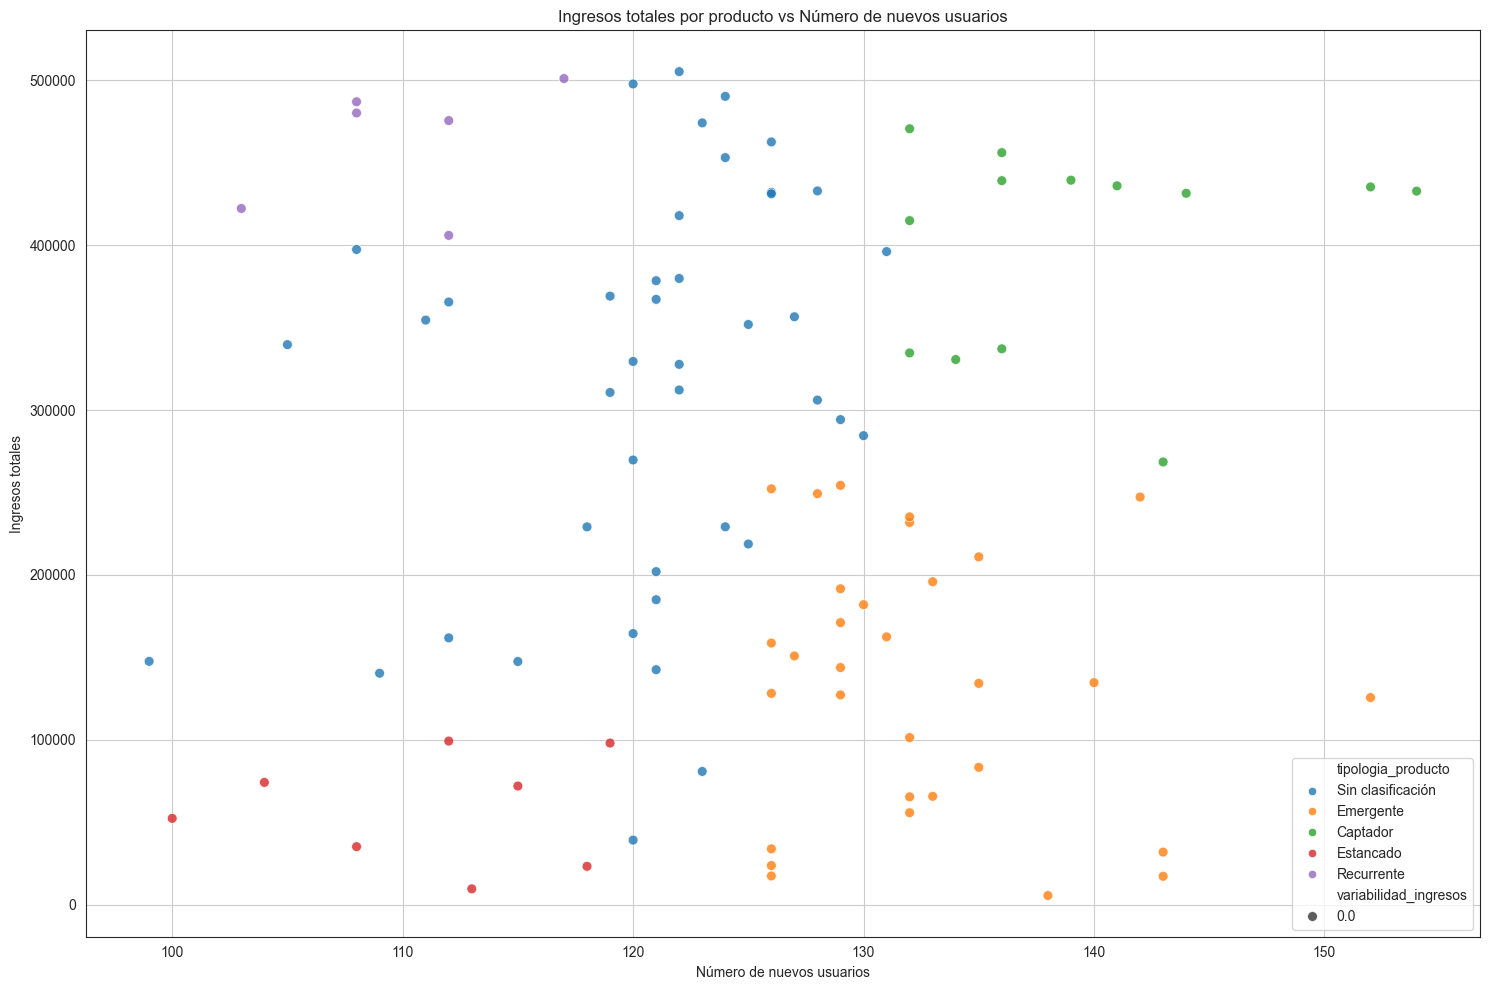

In [42]:
# Visualización del scatterplot

sns.set_style("white")
plt.figure(figsize=(15,10))
sns.scatterplot(
    x='num_nuevos_usuarios',
    y='ingresos_totales',
    data=df_product_metrics,
    alpha=0.8,
    hue='tipologia_producto',
    size='variabilidad_ingresos',
    sizes=(50,200)
)
plt.title("Ingresos totales por producto vs Número de nuevos usuarios")
plt.xlabel('Número de nuevos usuarios')
plt.ylabel('Ingresos totales')
plt.grid()
plt.tight_layout()
plt.show()

***Interpretación:***
*El scatterplot refleja la distribución de la tipología de producto que hemos implementado:*
- Productos con bajos ingresos y bajo número de nuevos compradores (ambos por debajo del primer cuartil): Estancado
- Productos con bajos ingresos (debajo de la media) y alto número de nuevos compradores (arriba de la media): Emergente
- Productos con alto número de nuevos compradores (arriba del tercer cuartil): Captador
- Productos con alto número de ingresos (arriba del tercer cuartil) y bajo número de nuevos compradores (debajo del primer cuartil): Recurrente
- En el medio vemos los productos Sin Clasificación, pues su desempeño no encaja en los parámetros anteriores, aunque algunos se acercan bastante.

*La distribución vista en el scatterplot nos permite concluir lo siguiente:*
- Una cantidad importante de los productos no encaja en las categorías planteadas, podríamos establecer nuevas tipologías para evaluar estos casos.
    - Muchos de ellos presentan una cantidad elevada de ingresos y se ubican por encima de la media de nuevos usuarios. Podríamos considerarlos los productos estrella.
- Son pocos los productos que son considerados como estancados, algunos de ellos podrían salir de catálogo.
- La cantidad de productos emergentes es elevada, valdría la pena para el negocio idear una estrategia para volverlos más recurrentes.
- La variabilidad de ingresos es 0, lo cual nos indica que cada producto tiene siempre el mismo precio  .

### Ex. 2: Análisis geográfico compañía–usuario y oportunidades de expansión

**Objetivo:** Analizar la relación entre el país de las compañías vendedoras, el país de residencia de los usuarios y el flujo de compra entre países.
¿El negocio está basado en mercados locales (mismo país usuario–compañía) o hay una oportunidad real de expansión internacional abriendo más compañías en ciertos países?

Pasos orientativos:
- Combina las tablas necesarias.
- Crea una variable clave de análisis: compra_local = True/False.
- Analiza el comportamiento global:
    - Porcentaje de transacciones locales vs internacionales.
    - Porcentaje de facturación local vs internacional.
- Análisis por país del usuario, para cada país de usuario:
    - % de compras a compañías del mismo país.
    - % de compras a compañías extranjeras.
    - Importe total comprado.
- Análisis por país de compañía, para cada país de compañía calcula qué parte de su facturación viene de:
    - Usuarios locales.
    - Usuarios extranjeros.
- Escoge una visualización que explique claramente el fenómeno.
- Interpretación estratégica:
    - ¿En qué países valdría la pena abrir más compañías locales?
    - ¿Hay países con demanda pero poca oferta local?
    - ¿El negocio depende demasiado de compañías de un solo país?
    - ¿Abrir compañías locales reduciría fricción o mejoraría conversión?

In [43]:
# Hacemos una versión resumida del df de compañías, dejando sólo las columnas relevantes para el análisis

df_companies_brief = df_companies[['company_id', 'company_name', 'country']]
df_companies_brief

,company_id,company_name,country
0,b-2222,Ac Fermentum Incorporated,Germany
1,b-2226,Magna A Neque Industries,Australia
2,b-2230,Fusce Corp.,United States
3,b-2234,Convallis In Incorporated,Germany
4,b-2238,Ante Iaculis Nec Foundation,New Zealand
...,...,...,...
95,b-2602,Placerat LLP,Netherlands
96,b-2606,Sed Est Corp.,Canada
97,b-2610,Egestas Nunc Sed Limited,Italy
98,b-2614,Rutrum Non Inc.,Germany


In [44]:
# Hacemos merge y nos quedamos con las columnas necesarias:

df_geo_analisis = df_transactions_users.merge(df_companies_brief, on='company_id', how='inner')
df_geo_analisis = df_geo_analisis[['transaction_id', 'company_id', 'company_name', 'amount', 'declined', 'user_id', 'product_id', 'price', 'country_x', 'country_y']]
df_geo_analisis.rename(columns={'country_x': 'user_country', 'country_y': 'company_country'}, inplace=True)
df_geo_analisis

,transaction_id,company_id,company_name,amount,declined,user_id,product_id,price,user_country,company_country
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,b-2458,Eget Tincidunt Dui Institute,395.43,0,4713,16,180.91,France,Netherlands
1,00043A49-2949-494B-A5DD-A5BAE3BB19DD,b-2458,Eget Tincidunt Dui Institute,395.43,0,4713,26,53.01,France,Netherlands
2,00043A49-2949-494B-A5DD-A5BAE3BB19DD,b-2458,Eget Tincidunt Dui Institute,395.43,0,4713,97,65.25,France,Netherlands
3,00043A49-2949-494B-A5DD-A5BAE3BB19DD,b-2458,Eget Tincidunt Dui Institute,395.43,0,4713,87,96.26,France,Netherlands
4,00045D6B-ED2E-4F2F-8186-CEE074D875D0,b-2390,Neque Tellus Imperdiet Corp.,326.01,0,2118,30,79.53,United States,Ireland
...,...,...,...,...,...,...,...,...,...,...
252685,FFFC9E8D-27C7-4ADE-98F2-7533EF4DF126,b-2302,Nunc Interdum Incorporated,234.22,0,1008,16,180.91,Sweden,Germany
252686,FFFC9E8D-27C7-4ADE-98F2-7533EF4DF126,b-2302,Nunc Interdum Incorporated,234.22,0,1008,49,53.31,Sweden,Germany
252687,FFFCF76D-ECF0-4985-A2D0-B2A7B75998FC,b-2250,Amet Nulla Donec Corporation,148.91,0,680,18,148.91,Netherlands,Italy
252688,FFFD31D6-9495-47CE-B54A-7DB8E1CC274B,b-2450,Turpis Company,74.54,0,1103,48,21.53,United Kingdom,Netherlands


In [45]:
# Asignamos valor True a la columna de compra local si coinciden los países del usuario y de la compañía:

user_country = df_geo_analisis['user_country']
company_country = df_geo_analisis['company_country']

df_geo_analisis['local_purchase'] = False
df_geo_analisis.loc[user_country == company_country, 'local_purchase'] = True

df_geo_analisis

,transaction_id,company_id,company_name,amount,declined,user_id,product_id,price,user_country,company_country,local_purchase
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,b-2458,Eget Tincidunt Dui Institute,395.43,0,4713,16,180.91,France,Netherlands,False
1,00043A49-2949-494B-A5DD-A5BAE3BB19DD,b-2458,Eget Tincidunt Dui Institute,395.43,0,4713,26,53.01,France,Netherlands,False
2,00043A49-2949-494B-A5DD-A5BAE3BB19DD,b-2458,Eget Tincidunt Dui Institute,395.43,0,4713,97,65.25,France,Netherlands,False
3,00043A49-2949-494B-A5DD-A5BAE3BB19DD,b-2458,Eget Tincidunt Dui Institute,395.43,0,4713,87,96.26,France,Netherlands,False
4,00045D6B-ED2E-4F2F-8186-CEE074D875D0,b-2390,Neque Tellus Imperdiet Corp.,326.01,0,2118,30,79.53,United States,Ireland,False
...,...,...,...,...,...,...,...,...,...,...,...
252685,FFFC9E8D-27C7-4ADE-98F2-7533EF4DF126,b-2302,Nunc Interdum Incorporated,234.22,0,1008,16,180.91,Sweden,Germany,False
252686,FFFC9E8D-27C7-4ADE-98F2-7533EF4DF126,b-2302,Nunc Interdum Incorporated,234.22,0,1008,49,53.31,Sweden,Germany,False
252687,FFFCF76D-ECF0-4985-A2D0-B2A7B75998FC,b-2250,Amet Nulla Donec Corporation,148.91,0,680,18,148.91,Netherlands,Italy,False
252688,FFFD31D6-9495-47CE-B54A-7DB8E1CC274B,b-2450,Turpis Company,74.54,0,1103,48,21.53,United Kingdom,Netherlands,False


In [46]:
# Análisis de comportamiento global: porcentajes de compras y facturación locales o internacionales

num_compras_total = len(df_geo_analisis['local_purchase'])
print(f'Número total de compras: {num_compras_total}')
num_compras_locales = df_geo_analisis['local_purchase'].sum()
print(f'Número de compras locales: {num_compras_locales}')
num_compras_int = num_compras_total - num_compras_locales
print(f'Número de compras internacionales: {num_compras_int}')
print(f'Porcentaje de compras locales: {round((num_compras_locales / num_compras_total) * 100, 2)} %')
print(f'Porcentaje de compras internacionales: {round((num_compras_int / num_compras_total) * 100, 2)} %')
print('')
facturacion_total = df_geo_analisis['price'].sum()
compras_locales = df_geo_analisis[(df_geo_analisis['local_purchase'] == True)]
compras_internacionales = df_geo_analisis[(df_geo_analisis['local_purchase'] == False)]
facturacion_local = compras_locales['price'].sum()
facturacion_internacional = compras_internacionales['price'].sum()
print(f'Facturación total: {facturacion_total} €')
print(f'Facturación local: {facturacion_local} €')
print(f'Facturación internacional: {facturacion_internacional} €')
print(f'Porcentaje facturación local: {round((facturacion_local / facturacion_total) *100, 2)} %')
print(f'Porcentaje facturación internacional: {round((facturacion_internacional / facturacion_total) *100, 2)} %')

Número total de compras: 252690
Número de compras locales: 30193
Número de compras internacionales: 222497
Porcentaje de compras locales: 11.95 %
Porcentaje de compras internacionales: 88.05 %

Facturación total: 25830228.79 €
Facturación local: 3087420.41 €
Facturación internacional: 22742808.38 €
Porcentaje facturación local: 11.95 %
Porcentaje facturación internacional: 88.05 %


In [47]:
# Análisis por país del usuario:

df_analisis_pais_u = df_geo_analisis.groupby('user_country').agg(importe_total=('price', 'sum'), compras_totales=('local_purchase', 'count'), compras_mismo_pais=('local_purchase', 'sum')).reset_index()
df_analisis_pais_u['compras_internacionales'] = df_analisis_pais_u['compras_totales'] - df_analisis_pais_u['compras_mismo_pais']
df_analisis_pais_u['porcentaje_compras_locales'] = round((df_analisis_pais_u['compras_mismo_pais'] / df_analisis_pais_u['compras_totales']) * 100, 2)
df_analisis_pais_u['porcentaje_compras_internacionales'] = round((df_analisis_pais_u['compras_internacionales'] / df_analisis_pais_u['compras_totales']) * 100, 2)
df_analisis_pais_u

,user_country,importe_total,compras_totales,compras_mismo_pais,compras_internacionales,porcentaje_compras_locales,porcentaje_compras_internacionales
0,Canada,2574851.95,25282,2415,22867,9.55,90.45
1,France,2170797.37,21343,1328,20015,6.22,93.78
2,Germany,2262518.00,22031,3796,18235,17.23,82.77
3,Italy,2232257.75,21717,3719,17998,17.12,82.88
4,Netherlands,2310893.01,22754,4432,18322,19.48,80.52
5,Poland,2137011.87,20843,0,20843,0.00,100.00
6,Portugal,2247753.11,22000,0,22000,0.00,100.00
7,Spain,2331801.73,22691,422,22269,1.86,98.14
8,Sweden,2087356.47,20462,4352,16110,21.27,78.73
9,United Kingdom,2472213.80,24208,4209,19999,17.39,82.61


<Figure size 1500x1000 with 0 Axes>

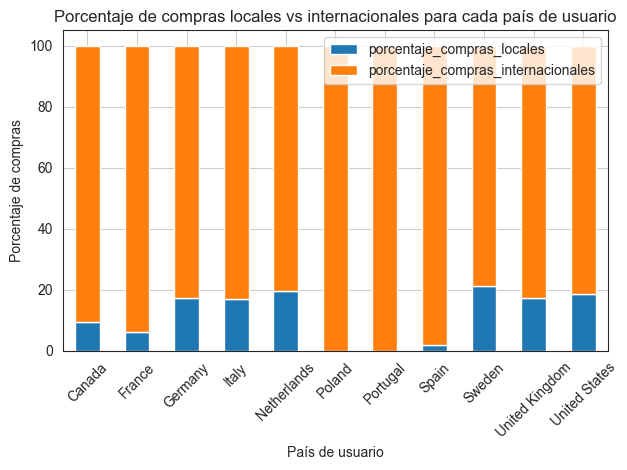

In [48]:
# Visualización de barras apiladas

sns.set_style("white")
plt.figure(figsize=(15,10))
df_analisis_pais_u.plot.bar(
    x='user_country',
    y=['porcentaje_compras_locales', 'porcentaje_compras_internacionales'],
    title='Porcentaje de compras locales vs internacionales para cada país de usuario',
    stacked=True
    )
plt.xlabel('País de usuario')
plt.ylabel('Porcentaje de compras')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

In [49]:
# Análisis por país de compañía:

df_usuarios_locales = df_geo_analisis.loc[user_country == company_country]
df_usuarios_internacionales = df_geo_analisis.loc[user_country != company_country]

df_fact_local = df_usuarios_locales.groupby('company_country').agg(facturacion_usuarios_locales=('price', 'sum'))
df_fact_int = df_usuarios_internacionales.groupby('company_country').agg(facturacion_usuarios_internacionales=('price', 'sum'))

df_fact_pais_c = df_fact_local.merge(df_fact_int, on='company_country', how='outer').reset_index()
df_fact_pais_c = df_fact_pais_c.fillna(0)

df_fact_pais_c['total_facturacion'] = df_fact_pais_c['facturacion_usuarios_locales'] + df_fact_pais_c['facturacion_usuarios_internacionales']
df_fact_pais_c['porcentaje_facturacion_local'] = round((df_fact_pais_c['facturacion_usuarios_locales'] / df_fact_pais_c['total_facturacion']) * 100, 2)
df_fact_pais_c['porcentaje_facturacion_internacional'] = round((df_fact_pais_c['facturacion_usuarios_internacionales'] / df_fact_pais_c['total_facturacion']) * 100, 2)
df_fact_pais_c

,company_country,facturacion_usuarios_locales,facturacion_usuarios_internacionales,total_facturacion,porcentaje_facturacion_local,porcentaje_facturacion_internacional
0,Australia,0.00,675522.04,675522.04,0.00,100.00
1,Belgium,0.00,917313.83,917313.83,0.00,100.00
2,Canada,247103.90,293979.28,541083.18,45.67,54.33
3,China,0.00,230623.74,230623.74,0.00,100.00
4,France,134555.17,1085702.27,1220257.44,11.03,88.97
5,Germany,392394.21,3068547.08,3460941.29,11.34,88.66
6,Ireland,0.00,690290.58,690290.58,0.00,100.00
7,Italy,381065.45,3140507.46,3521572.91,10.82,89.18
8,Netherlands,452134.81,3431438.48,3883573.29,11.64,88.36
9,New Zealand,0.00,681929.92,681929.92,0.00,100.00


<Figure size 1500x1000 with 0 Axes>

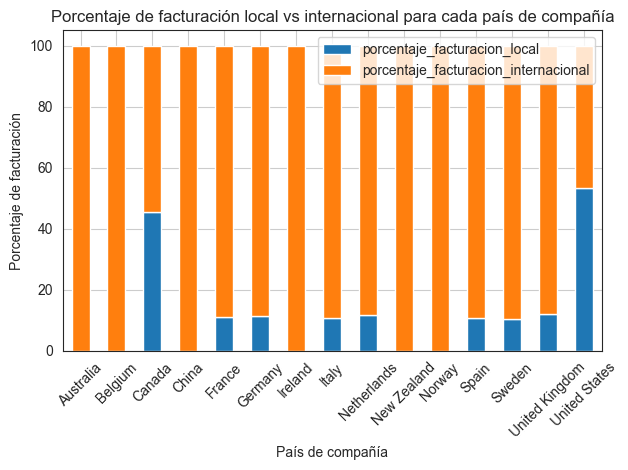

In [50]:
# Visualización de barras apiladas

sns.set_style("white")
plt.figure(figsize=(15,10))
df_fact_pais_c.plot.bar(
    x='company_country',
    y=['porcentaje_facturacion_local', 'porcentaje_facturacion_internacional'],
    title='Porcentaje de facturación local vs internacional para cada país de compañía',
    stacked=True
    )
plt.xlabel('País de compañía')
plt.ylabel('Porcentaje de facturación')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

In [51]:
# Análisis por país: número de compañías, clientes y facturación

empresas_pais = df_geo_analisis.groupby('company_country').agg(total_companies=('company_id', 'nunique'), total_earnings=('price', 'sum')).reset_index()
num_clientes_pais = df_geo_analisis.groupby('user_country').agg(total_clients=('user_id', 'count')).reset_index()

clientes_companias_pais = empresas_pais.merge(num_clientes_pais, left_on='company_country', right_on='user_country', how='outer')
clientes_companias_pais['country'] = clientes_companias_pais['company_country'].combine_first(clientes_companias_pais['user_country'])
clientes_companias_pais = clientes_companias_pais[['country', 'total_companies', 'total_clients', 'total_earnings']].fillna(0)
clientes_companias_pais

,country,total_companies,total_clients,total_earnings
0,Australia,6.0,0.0,675522.04
1,Belgium,8.0,0.0,917313.83
2,Canada,5.0,25282.0,541083.18
3,China,2.0,0.0,230623.74
4,France,3.0,21343.0,1220257.44
5,Germany,8.0,22031.0,3460941.29
6,Ireland,6.0,0.0,690290.58
7,Italy,9.0,21717.0,3521572.91
8,Netherlands,10.0,22754.0,3883573.29
9,New Zealand,6.0,0.0,681929.92


In [52]:
# Obtenemos un df con todos los datos calculados para cada país: número de empresas, clientes, facturación total, facturación local e internacional y sus respectivos porcentajes del total

df_paises_resumen = clientes_companias_pais.merge(df_fact_pais_c, left_on='country', right_on='company_country', how='left')
df_paises_resumen = df_paises_resumen.drop(columns=['company_country', 'total_earnings']).fillna(0)
df_paises_resumen.rename(columns={'country': 'pais', 'total_companies': 'total_empresas', 'total_clients': 'total_clientes'}, inplace=True)
df_paises_resumen

,pais,total_empresas,total_clientes,facturacion_usuarios_locales,facturacion_usuarios_internacionales,total_facturacion,porcentaje_facturacion_local,porcentaje_facturacion_internacional
0,Australia,6.0,0.0,0.00,675522.04,675522.04,0.00,100.00
1,Belgium,8.0,0.0,0.00,917313.83,917313.83,0.00,100.00
2,Canada,5.0,25282.0,247103.90,293979.28,541083.18,45.67,54.33
3,China,2.0,0.0,0.00,230623.74,230623.74,0.00,100.00
4,France,3.0,21343.0,134555.17,1085702.27,1220257.44,11.03,88.97
5,Germany,8.0,22031.0,392394.21,3068547.08,3460941.29,11.34,88.66
6,Ireland,6.0,0.0,0.00,690290.58,690290.58,0.00,100.00
7,Italy,9.0,21717.0,381065.45,3140507.46,3521572.91,10.82,89.18
8,Netherlands,10.0,22754.0,452134.81,3431438.48,3883573.29,11.64,88.36
9,New Zealand,6.0,0.0,0.00,681929.92,681929.92,0.00,100.00


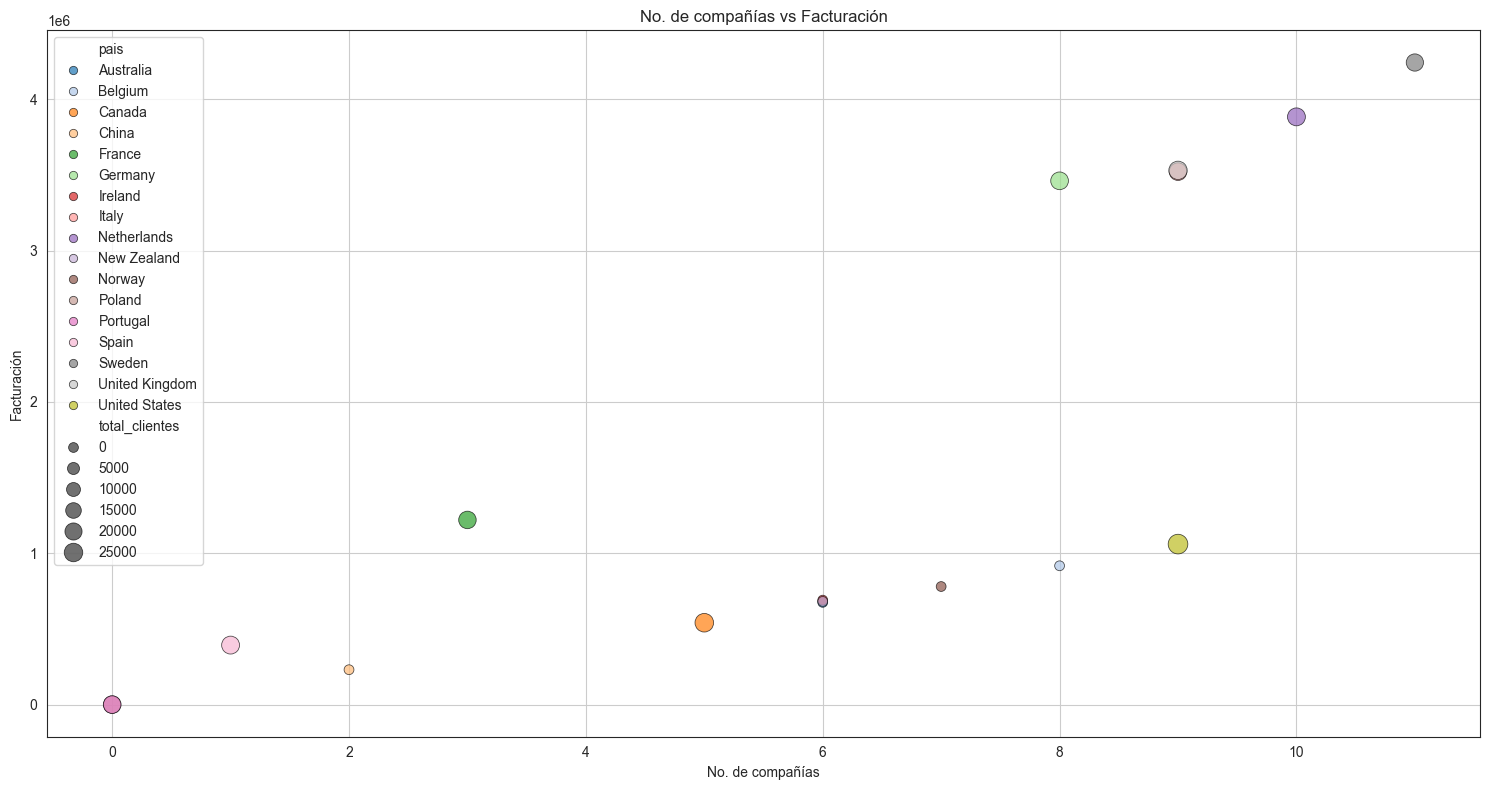

In [53]:
# Visualización del scatterplot

sns.set_style("white")
plt.figure(figsize=(15,8))
sns.scatterplot(
    x='total_empresas',
    y='total_facturacion',
    data=df_paises_resumen,
    palette='tab20',
    alpha=0.7,
    hue='pais',
    size='total_clientes',
    edgecolor='black',
    sizes=(50,200)
)
plt.title("No. de compañías vs Facturación")
plt.xlabel('No. de compañías')
plt.ylabel('Facturación')
plt.grid()
plt.tight_layout()
plt.show()

***Interpretación:***

- En los pasos anteriores, hemos podido apreciar que la mayor parte de la facturación del negocio proviene de transacciones internacionales, el 88.05% del total.
- Sin embargo, no todos los países siguen esta tendencia: Estados Unidos factura un poco más localmente, con un 53.25% de sus ingresos totales. Canadá también presenta un equilibrio en el origen de su facturación.
- Notamos también que hay países con transacciones y facturación 100% internacional: Australia, Bélgica, China, Irlanda, Nueva Zelanda y Noruega. Es decir, no tienen clientes locales.
- Los porcentajes de facturación y transacciones locales e internacionales coinciden, debido posiblemente a que el precio entre productos no varía mucho.
- Por otro lado, los usuarios tienden a comprar de compañías extranjeras, aún teniendo opciones locales. Sólo los países de mayor facturación (Reino Unido, Estados Unidos, Alemania, Italia, Suecia y Países Bajos) tienen un consumo local cercano al 20%.


*1. ¿En qué países valdría la pena abrir más compañías locales?*

*R. Polonia y Portugal son opciones interesantes, pues no tienen ninguna compañía local pero presentan una gran cantidad de clientes. España también podría presentar una oportunidad de negocio, pues sólo cuenta con una empresa y factura local e internacionalmente.*

*2. ¿Hay países con demanda pero poca oferta local?*

*R. Sí, están los casos antes mencionados de España, Portugal y Polonia, que tienen una cantidad razonable de clientes pero ninguna (o 1 en el caso de España) compañías. Francia también podría encajar aquí, aunque cuenta con 3 empresas.*

*3. ¿El negocio depende demasiado de compañías de un solo país?*

*R. Como hemos evaluado en ejercicios anteriores, 5 países concentran el 72,01% de las operaciones y facturación del negocio. No se trata de uno sólo, pero perder la operación de cualquiera de esos países impactaría profundamente el negocio.*

*4. ¿Abrir compañías locales reduciría fricción o mejoraría conversión?*

*R. Depende de los canales de venta de nuestro negocio y en los datos que tengamos respecto a las transacciones no concretadas. Abrir compañías locales podría disminuir la fricción si se traduce en tener mayor disponibilidad de producto o reducir gastos de envío. Respecto a la conversión, tendríamos que tener datos relativos (ie. si tenemos un e-commerce, saber si los usuarios abandonan la compra por falta de disponibilidad local o altos gastos de envío).*

## Nivel 3 - Visualización ejecutiva y storytelling

### Ex. 1: Mini-dashboard departamental

**Objectivo:** Construye un mini-dashboard en Python utilizando Google Colab. Este ejercicio está pensado para que todo el desarrollo principal se haga dentro del notebook, utilizando Colab como herramienta de análisis y visualización.

La opción principal y recomendada es la siguiente:

- Figura única con subplots (enfoque analítico clásico). Construcción de una única figura con 4 subplots utilizando matplotlib y/o seaborn.
    - Requisitos:
        - 1 figura
        - 4 visualizaciones diferentes
    - Si tienes tiempo y quieres profundizar en una solución una poco más compleja, al final se presentan alternativas avanzadas opcionales:
        - Google Colab está pensado principalmente para trabajo analítico en notebooks. Por este motivo, la construcción de dashboards con Streamlit o Dash no es recomendada dentro de Colab, ya que requiere la ejecución de aplicaciones web en un entorno local.
        - Las opciones de dashboard con Streamlit o Dash se consideran alternativas avanzadas y opcionales, y sólo se han de desarrollar en entorno local de Python.
- Dashboard interactivo con Streamlit. Construcción de una aplicación simple con Streamlit, orientada a exploración interactiva.
    - Requisitos:
        - 1 página Streamlit
        - Al menos:
            - 2 filtros
            - 3-4 visualizaciones
        - Uso de st.sidebar o selectores
- Dashboard con DashConstrucción de un dashboard web con Plotly Dash.
    - Requisitos:
        - Layout con components.
        - Callbacks simples.
        - Al menos 3 visualizaciones conectadas.

**Condición común en TODAS las opciones.** Independientemente de la opción elegida, el mini-dashboard va orientado a UNO de los siguientes departamentos:
- Marketing
- Ventas / Comercial
- Producción
- Sistemas / Ciberseguridad

Las visualizaciones han de ser:
- Relevantes para el departamento elegido.
- Claras y legibles.
- Coherentes entre sí.

No se valora la complejidad gráfica, sino:
- La selección adecuada de métricas.
- La capacidad de síntesis.
- La coherencia del mensaje.

### Gráficos a utilizar en el dashboard de Ventas / Marketing:

Facturación:
- Evolución temporal de ventas por meses del periodo 2020-2024 (heatmap)
- Porcentaje de compras local vs internacional por país de usuario (barras apiladas)
- Porcentaje de facturación local vs internacional por país de compañía (barras apiladas)
- No. de compañías vs facturación (scatterplot)


Producto:
- Ingresos totales por producto vs número de usuarios nuevos (scatterplot)
- Tipología de producto (scatterplot)
- Top 15 de productos por facturación (lineplot)

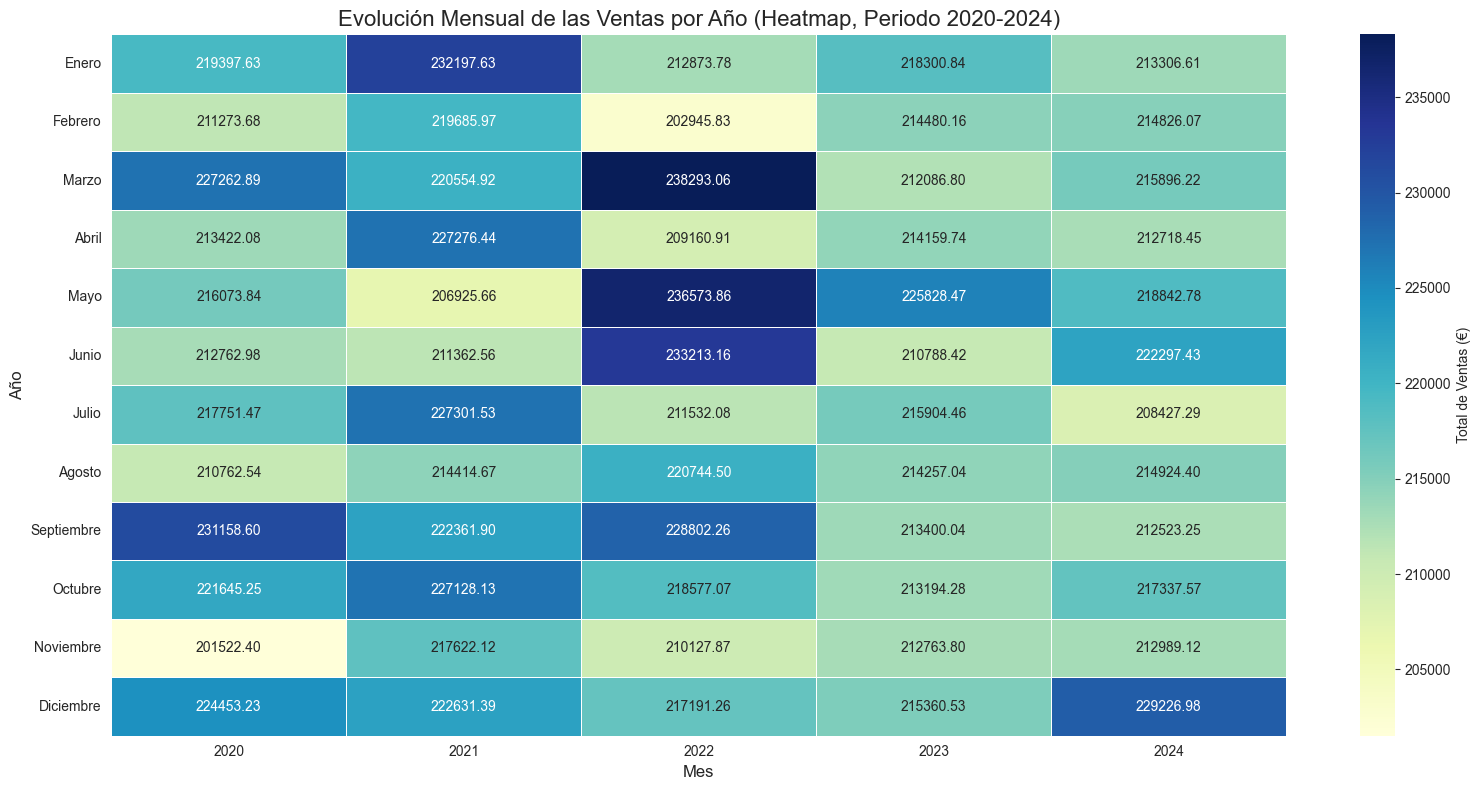

In [57]:
# Primero vamos a retrabajar la evolución mensual de facturación por año, que habíamos hecho como un gráfico lineal con una línea por año, poco legible.
# Evaluaremos sólo los últimos 5 años con un heatmap y pivotaremos los datos para tener el gráfico en formato alargado vertical

locale.setlocale(locale.LC_TIME, 'es_ES.UTF-8')

current_year = pt_transactions_dates.index.max()
start_year = current_year - 4
df_ventas_mensuales_5 = pt_transactions_dates[pt_transactions_dates.index >= start_year]
df_ventas_heatmap_t = df_ventas_mensuales_5.T

plt.figure(figsize=(16, 8))
sns.heatmap(
    df_ventas_heatmap_t,
    cmap="YlGnBu",
    annot=True,
    fmt=".2f",
    linewidths=.5,
    cbar_kws={'label': 'Total de Ventas (€)'}
)
plt.title(f'Evolución Mensual de las Ventas por Año (Heatmap, Periodo {start_year}-{current_year})', fontsize=16)
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Año', fontsize=12)
plt.tight_layout()
plt.show()

In [55]:
# Después hacemos un merge al df_paises_resumen para añadir porcentajes de compras de usuario, y así tener un análisis completo por países.

df_paises_resumen = df_paises_resumen.merge(df_analisis_pais_u, left_on='pais', right_on='user_country', how='left')
df_paises_resumen = df_paises_resumen.drop('user_country', axis=1).fillna(0)
df_paises_resumen

,pais,total_empresas,total_clientes,facturacion_usuarios_locales,facturacion_usuarios_internacionales,total_facturacion,porcentaje_facturacion_local,porcentaje_facturacion_internacional,importe_total,compras_totales,compras_mismo_pais,compras_internacionales,porcentaje_compras_locales,porcentaje_compras_internacionales
0,Australia,6.0,0.0,0.00,675522.04,675522.04,0.00,100.00,0.00,0.0,0.0,0.0,0.00,0.00
1,Belgium,8.0,0.0,0.00,917313.83,917313.83,0.00,100.00,0.00,0.0,0.0,0.0,0.00,0.00
2,Canada,5.0,25282.0,247103.90,293979.28,541083.18,45.67,54.33,2574851.95,25282.0,2415.0,22867.0,9.55,90.45
3,China,2.0,0.0,0.00,230623.74,230623.74,0.00,100.00,0.00,0.0,0.0,0.0,0.00,0.00
4,France,3.0,21343.0,134555.17,1085702.27,1220257.44,11.03,88.97,2170797.37,21343.0,1328.0,20015.0,6.22,93.78
5,Germany,8.0,22031.0,392394.21,3068547.08,3460941.29,11.34,88.66,2262518.00,22031.0,3796.0,18235.0,17.23,82.77
6,Ireland,6.0,0.0,0.00,690290.58,690290.58,0.00,100.00,0.00,0.0,0.0,0.0,0.00,0.00
7,Italy,9.0,21717.0,381065.45,3140507.46,3521572.91,10.82,89.18,2232257.75,21717.0,3719.0,17998.0,17.12,82.88
8,Netherlands,10.0,22754.0,452134.81,3431438.48,3883573.29,11.64,88.36,2310893.01,22754.0,4432.0,18322.0,19.48,80.52
9,New Zealand,6.0,0.0,0.00,681929.92,681929.92,0.00,100.00,0.00,0.0,0.0,0.0,0.00,0.00


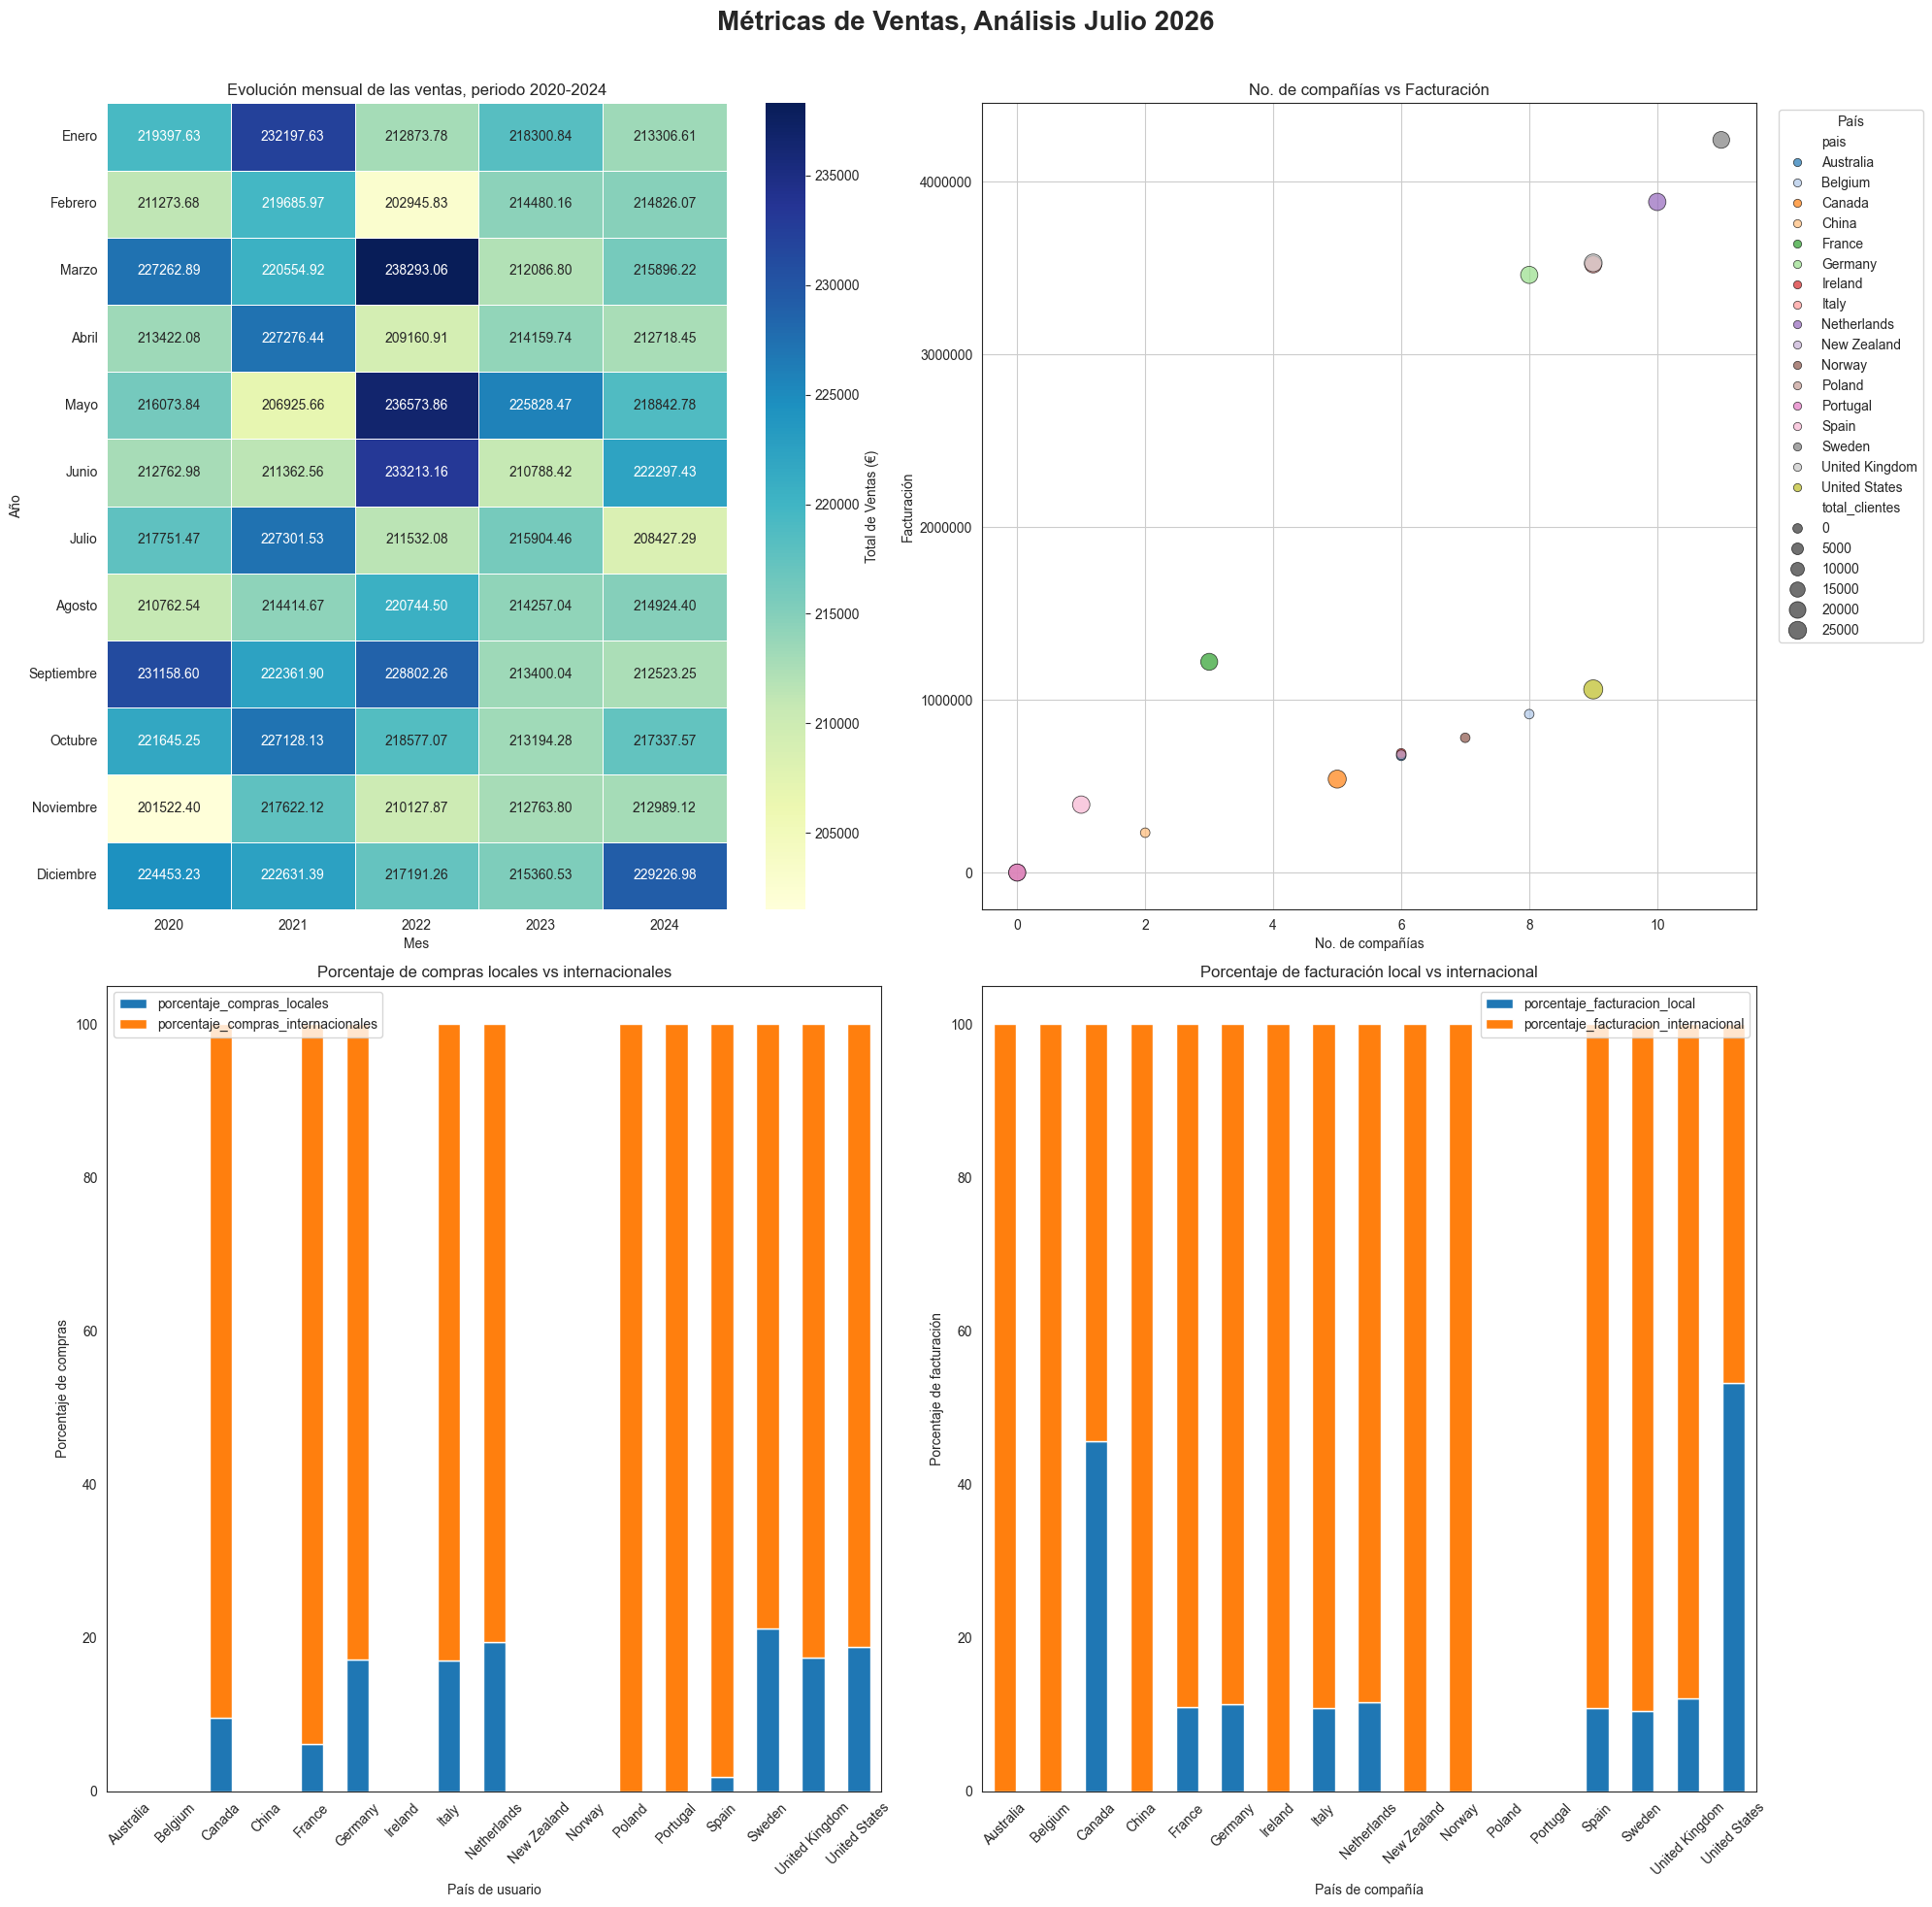

In [56]:
# Estructura para dashboard con supblots:

fig, axes = plt.subplots(2, 2, figsize=(20, 20))
fig.suptitle("Métricas de Ventas, Análisis Julio 2026", fontsize=20, fontweight='bold')
sns.set_style('white')

grafico_1 = axes[0, 0]
grafico_2 = axes[0, 1]
grafico_3 = axes[1, 0]
grafico_4 = axes[1, 1]

# Gráfico 1
sns.heatmap(
    df_transposed_heatmap,
    cmap="YlGnBu",
    annot=True,
    fmt=".2f",
    linewidths=.5,
    cbar_kws={'label': 'Total de Ventas (€)'},
    ax=grafico_1
)
grafico_1.set_xlabel('Mes')
grafico_1.set_ylabel('Año')
grafico_1.set_title("Evolución mensual de las ventas, periodo 2020-2024")

# Gráfico 2
sns.scatterplot(
    x='total_empresas',
    y='total_facturacion',
    data=df_paises_resumen,
    palette='tab20',
    alpha=0.7,
    hue='pais',
    size='total_clientes',
    edgecolor='black',
    sizes=(50,200),
    ax=grafico_2
    )
grafico_2.set_title('No. de compañías vs Facturación')
grafico_2.set_xlabel('No. de compañías')
grafico_2.set_ylabel('Facturación')
grafico_2.ticklabel_format(style='plain', axis='y')
grafico_2.legend(
    title='País',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)
grafico_2.grid()

# Gráfico 3
df_paises_resumen.plot.bar(
    x='pais',
    y=['porcentaje_compras_locales', 'porcentaje_compras_internacionales'],
    title='Porcentaje de compras locales vs internacionales',
    stacked=True,
    ax= grafico_3
)
grafico_3.set_xlabel('País de usuario')
grafico_3.set_ylabel('Porcentaje de compras')
grafico_3.tick_params(axis='x', rotation=45)

# Gráfico 4
df_paises_resumen.plot.bar(
    x='pais',
    y=['porcentaje_facturacion_local', 'porcentaje_facturacion_internacional'],
    title='Porcentaje de facturación local vs internacional',
    stacked=True,
    ax= grafico_4
)
grafico_4.set_xlabel('País de compañía')
grafico_4.set_ylabel('Porcentaje de facturación')
grafico_4.tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('dashboard_ventas.png', dpi=300)
plt.show()

### Ex. 2: Informe ejecutivo

**Objectivo:** A partir del dashboard, presenta un informe ejecutivo en dos versiones:

- Sin IA
- Con soporte de IA

Sin IA: Redactada con tus propias palabras.

Con soporte de IA: Utilizando herramientas de IA para:

- Mejorar la redacción.
- Adaptar el lenguaje al departamento escogido.
- Incorporar vocabulario técnico de negocio.

El informe ha de contener obligatoriamente:

- Resumen general (máx. 5 líneas): Qué se ha analizado y con qué objectivo.
- Hallazgos clave (3-5): Insights sólidos basados en datos reales.
- Riesgos detectados: Por ejemplo: dependencia excesiva de productos o empresas, falta de captación de nuevos usuarios, franjas horarias críticas, posibles indicios de fraude o anomalías...
- Oportunidades: mejoras operativas, segmentos no explotados, productos o franjas con potencial, optimización de recursos...
- Recomendaciones: Acciones concretas y no técnicas, orientadas a negocio.

**Clave del nivel 3:**

No se trata de demostrar que sabes hacer gráficos, sino de demostrar que entiendes los datos y sabes explicar qué se ha de hacer con ellos.
- Implementar estrategias comerciales orientadas a la fidelización y a la previsibilidad del volumen de ventas.

## Informe ejecutivo (sin IA):

Con este dashboard, buscamos representar datos significativos relacionados con las ventas realizadas por las empresas del grupo.

- En el primer gráfico, mostramos la evolución mensual de las ventas durante los últimos 5 años de registro.
  - Los picos más altos de ventas se dieron en el año 2022, en los meses de marzo y mayo.
  - Por otro lado, las caídas más pronunciadas se dieron en noviembre de 2020 y febrero de 2022.
  - Los 2 últimos años de operación han sido los más estables en cuanto a ventas, con variaciones muy pequeñas en la facturación.
  - No encontramos patrones de estacionalidad relevantes.

- En el segundo gráfico, mostramos la dispersión entre el número de compañías del grupo presentes en cada país, en relación a la facturación y la cantidad de clientes.
  - Notamos que no existe una relación perfectamente lineal entre tener una mayor cantidad de compañías y facturar más.
  - Estados Unidos aparece como el país con más compañías y mayor facturación. Reino Unido sigue esa tendencia. Sin embargo, tenemos países con número de empresas similar pero cuya facturación cambia mucho.
  - Podemos con eso inferir que no necesariamente el abrir más empresas resulta en mayor facturación, habría que considerar otros aspectos como ticket medio, poder adquisitivo, hábitos de consumidor, etc.

- En el tercer gráfico, mostramos el porcentaje de compras locales vs internacionales que hacen los usuarios de cada país.
  - Lo primero que podemos ver es que no tenemos usuarios en Australia, Bélgica, China, Irlanda, Nueva Zelanda y Noruega, países en los que sí tenemos empresas.
  - La mayoría de los usuarios tiende a realizar compras internacionales, al menos en un 80% de las que realizan.
  - Llama la atención el caso de los usuarios españoles, que no llegan a hacer ni un 2% de compras a empresas locales.

- El último gráfico muestra el porcentaje de facturación local vs internacional para cada país en los que tenemos empresas (y mostramos también los que no pero que sí tienen usuarios)
  - En correspondencia a lo visto en el gráfico anterior, los países sin usuarios tienen un 100% de facturación internacional.
  - En la mayoría de los países, sus empresas facturan más con clientes internacionales que locales, aún teniendo opciones.
  - Solamente Estados Unidos y Canadá presentan un equilibrio en su facturación, entre el 40 y el 55%.
  - Adicionalmente, el resto de países con mayor facturación (Reino Unido, Alemania, Italia, Suecia y Países Bajos) tienen un consumo local cercano al 20%.

## Informe ejecutivo (con soporte de IA):

Con este dashboard, buscamos representar algunos de los indicadores más relevantes relacionados con la actividad comercial y las ventas realizadas por las empresas del grupo.

**Evolución mensual de las ventas (2020-2024):**

En el primer gráfico se muestra la evolución mensual de las ventas durante los últimos cinco años registrados.

- Los mayores volúmenes de ventas se registraron en el año 2022, especialmente durante los meses de marzo y mayo.
- Por el contrario, las caídas más pronunciadas se observaron en noviembre de 2020 y febrero de 2022.
- Los dos últimos años analizados presentan una evolución más estable, con variaciones relativamente pequeñas en la facturación mensual.
- No se observan patrones estacionales consistentes a lo largo del periodo analizado. Aunque existen meses con picos o descensos puntuales, estos no se repiten de forma sistemática entre los distintos años.


**Relación entre número de compañías, facturación y clientes:**

El segundo gráfico representa la relación entre el número de compañías presentes en cada país, la facturación obtenida y el volumen de clientes.

- Se aprecia una tendencia positiva moderada entre el número de compañías y la facturación: en términos generales, los países con una mayor presencia empresarial tienden a generar mayores ingresos.
- Sin embargo, esta relación no es completamente lineal. Existen países con un número similar de compañías cuya facturación presenta diferencias significativas.
- Estados Unidos destaca como el país con mayor número de compañías y mayor facturación, seguido por Reino Unido. No obstante, otros países con una presencia empresarial comparable muestran niveles de ingresos considerablemente diferentes.
- Asimismo, el tamaño de las burbujas (número de clientes) tampoco explica por sí solo la facturación obtenida, lo que sugiere que intervienen otros factores como el ticket medio de compra, la frecuencia de consumo, el poder adquisitivo o las características propias de cada mercado.
- En consecuencia, aumentar el número de compañías en un país puede favorecer el crecimiento de la facturación, aunque esta decisión debería apoyarse en un análisis adicional del potencial y la rentabilidad de cada mercado.


**Compras locales vs. internacionales por país de usuario:**

El tercer gráfico muestra el porcentaje de compras realizadas por los usuarios a compañías de su mismo país frente a compañías extranjeras.

- En Australia, Bélgica, China, Irlanda, Nueva Zelanda y Noruega no existen usuarios registrados, a pesar de contar con compañías operando en dichos países.
- Se observa una clara preferencia por las compras internacionales en prácticamente todos los países, donde el porcentaje de compras realizadas a compañías extranjeras supera ampliamente al de las compras locales.
- Destaca especialmente el caso de España, donde las compras realizadas a compañías nacionales representan menos del 2% del total.


**Facturación local vs. internacional por país de compañía:**

El último gráfico representa el porcentaje de facturación que reciben las compañías de cada país procedente de clientes locales y de clientes internacionales.
